## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

Note:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

Importing Libraries

In [2]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

In [3]:
#Mounting the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#loading data into a pandas dataframe
stock_news = pd.read_csv("drive/MyDrive/GEN-AI-PG-Course/Project1/stock_news.csv")

In [5]:
# creating a copy of the stock news data
data = stock_news.copy()

## **Data Overview**

### Checking first 7 rows

In [6]:
data.head(7)

,Date,News,Open,High,Low,Close,Volume,Label
0,01-02-2019,The dollar minutes ago tumbled to 106 67 from above 109 a few trades earlier It s since bounced a hair to 107 16 FXY 3 6 after hoursAlongside money poured into U S government paper with the 10 year Treasury yield sliding a few more basis points to 2 61 TLT 0 7 after hour Both moves come following Apple NASDAQ AAPL s revenue warning which sent its shares and U S stock index futures into the red Apple s currently off 7 5 and the QQQs 2 2 ETFs TLT TBT TMV FXY YCS TBF EDV TMF TTT ZROZ VGLT OTC JYN TLH UBT SPTL YCL DLBS VUSTX TYBS DLBL OLD DJPY OPER UJPYNow read,38.72,39.71,38.56,39.48,130672400,1
1,01-02-2019,By Wayne Cole and Swati Pandey SYDNEY Reuters The Japanese yen soared in early Asian trading on Thursday as the break of key technical levels triggered massive stop loss sales of the U S and Australian dollars in very thin markets The dollar collapsed to as low as 105 25 yen on Reuters dealing a drop of 3 2 percent from the opening 108 76 and the lowest reading since March 2018 It was last trading around 107 50 yen Analysts said the rot began when tech bellwether Apple Inc O AAPL shocked investors by cutting its earnings guidance citing sluggish iPhone sales in China The news sent U S stock futures sliding and sparked a rush of funds to safe haven bonds With risk aversion high the safe haven yen was propelled through major technical levels and triggered massive stop loss flows from investors who have been short of the yen for months The move was exacerbated by a dearth of liquidity with Japan still on holiday after the New Year and by automated algorithmic trades which are carried out by computers in micro seconds Most major currencies simply collapsed against the yen in a matter of seconds Looks like we had a flash crash said Ray Attrill head of FX strategy at National Australia Bank One theory is that may be Japanese retail FX players are forcing out of AUDJPY which is creating a liquidity vacuum he added This is a market dislocation rather than a fundamental event The Australian dollar tumbled to as low as 72 26 yen AUDJPY D3 on Reuters dealing a level not seen since late 2011 having started around 75 21 It was last changing hands at 73 72 yen The Aussie in turn sank against the U S dollar to as far as 0 6715 the lowest since March 2009 having started around 0 6984 It was last trading at 0 6888 \nOther currencies smashed against the yen included the euro sterling and the Turkish lira,38.72,39.71,38.56,39.48,130672400,-1
2,01-02-2019,By Stephen Culp NEW YORK Reuters Wall Street edged higher on Wednesday after stumbling out of the starting gate on the first trading day of 2019 while fears of a global economic slowdown were exacerbated after Apple cut its holiday quarter revenue forecast Apple O AAPL dropped 8 percent in extended trading late in the day after the iPhone maker slashed its outlook for the December quarter blaming weak demand in China Shares of Apple s suppliers also fell and S P 500 futures dropped 1 3 percent signaling that Wednesday s modest advance could unwind when the market reopens on Thursday To see Apple s sales drop off this much says something about the Chinese economy said Tim Ghriskey chief investment strategist at Inverness Counsel in New York Any company that does business in China will feel the impact of this Stocks had started the session lower after separate reports showed a deceleration in factory activity in China and the euro zone indicating the ongoing trade dispute between the United States and China was taking a toll on global manufacturing Energy SPNY stocks led the S P 500 s advance and the sector was the index s biggest percentage gainer buoyed by a 2 4 percent jump in crude prices The group was the worst performing S P sector in 2018 Gains were offset by healthcare SPXHC and so called defensive sectors such as real estate utilities SPLRCU and consumer staples SPLRCS Healthcare companies provided the biggest drag on the S P 500 a

We can see that the dataset contains 8 columns: date, news, open, high, low, close, volume, and label.

The label column has three possible values: 1, 0, and -1, which represent positive, neutral, and negative sentiment respectively.

### Checking the shape of data

In [7]:
data.shape

(418, 8)

The dataset has 418 rows and 8 columns.

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    418 non-null    object 
 1   News    418 non-null    object 
 2   Open    418 non-null    float64
 3   High    418 non-null    float64
 4   Low     418 non-null    float64
 5   Close   418 non-null    float64
 6   Volume  418 non-null    int64  
 7   Label   418 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 26.3+ KB


All columns contain 418 non-null values, which matches the total number of rows. This confirms that there are no missing values in the dataset. This we can also confirm from data.isnull().sum()

In [9]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


In [10]:
data.describe()

,Open,High,Low,Close,Volume,Label
count,418.000000,418.000000,418.000000,418.000000,4.180000e+02,418.000000
mean,42.308852,42.787321,41.923732,42.418517,1.294225e+08,0.308612
std,4.947134,4.947413,4.967880,4.999867,4.574550e+07,0.943473
min,35.990000,36.430000,35.500000,35.550000,4.544800e+07,-1.000000
25%,38.130000,38.420000,37.720000,38.270000,1.029072e+08,-1.000000
50%,41.530000,42.250000,41.140000,41.610000,1.156272e+08,1.000000
75%,47.190000,47.427500,46.480000,47.032500,1.511252e+08,1.000000
max,51.840000,52.120000,51.760000,51.870000,3.652488e+08,1.000000


The stock prices (Open, High, Low, Close) have mean values close to 42, with a standard deviation of around 5, indicating moderate price variation. The prices range from approximately 35.5 to 52.1, showing the overall trading range during the period.

The Volume column shows high variability, ranging from about 45 million to 365 million, suggesting large fluctuations in trading activity.

In [11]:
data.duplicated().sum()

0

This confirms there are no duplicate rows in the dataset

In [12]:
data['Date'].nunique()

73

Based on data overview we found that there are no null values, no duplicates. We have a total of 418 rows which contains data across 73 days.

## **Exploratory Data Analysis**

The goal of this project is to build an NLP-based sentiment analysis system that can classify stock market news into three sentiment categories: Positive, Negative, and Neutral. The objective is to train and evaluate machine learning models that can accurately predict sentiment for unseen news. This can help in understanding market perception, supporting trading decisions, and enabling automated monitoring of financial news streams. Here we start by doing data analysis to understand relationship between variables such as Open, High, Low, Close, Volume and Label.

### **Univariate Analysis**

First we check the distribution of the sentiment label.

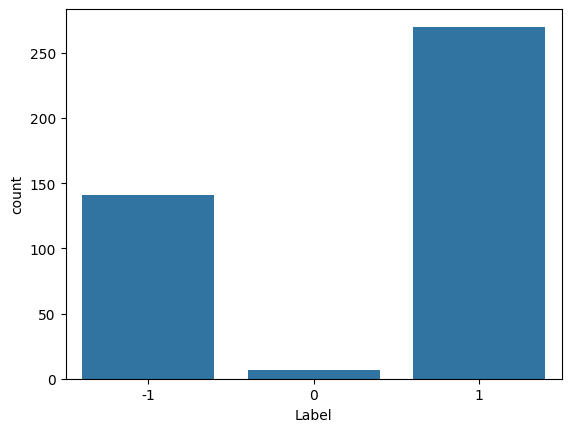

In [13]:
sns.countplot(data=data, x='Label');

The countplot shows that the dataset is highly imbalanced. Most of the records belong to the positive class, followed by the negative class . The neutral class has very few samples, making it the least represented category.

Checking the distribution of news by date.

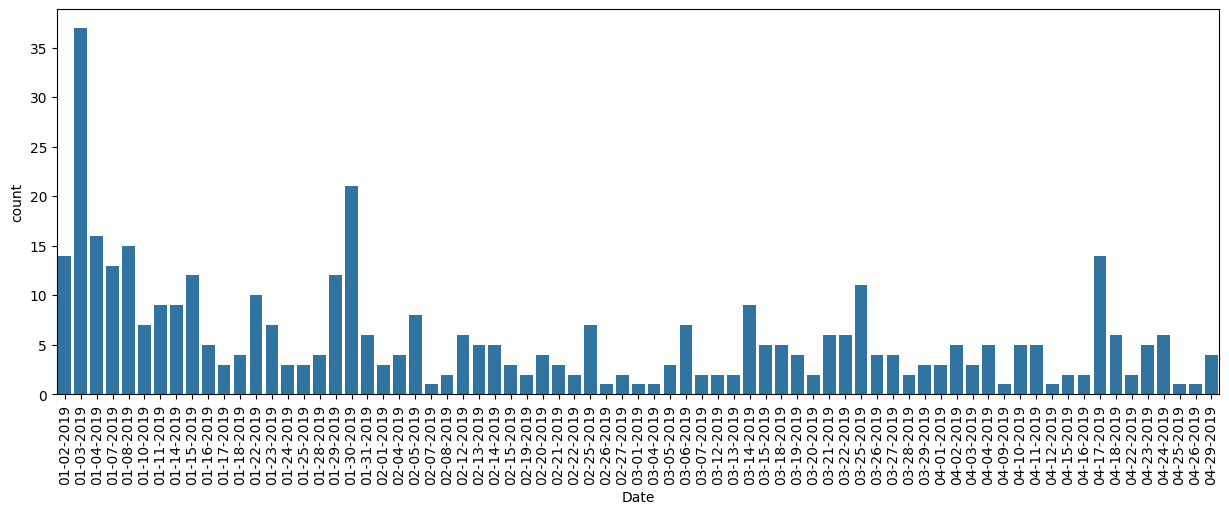

In [14]:
plt.figure(figsize=(15, 5))
plt.xticks(rotation=90)
sns.countplot(data=data, x='Date');

The bar plot shows that the number of news records per date is not evenly distributed. Some dates contain a high number of news entries, while many dates have only a few records. This indicates that the dataset is temporally imbalanced, meaning certain days have significantly more news coverage than others. This means we have to be careful while splitting the data as we should be splitting by 80% of news count and not 80% of date count.

Calulating the length of news

<Axes: xlabel='News', ylabel='Count'>

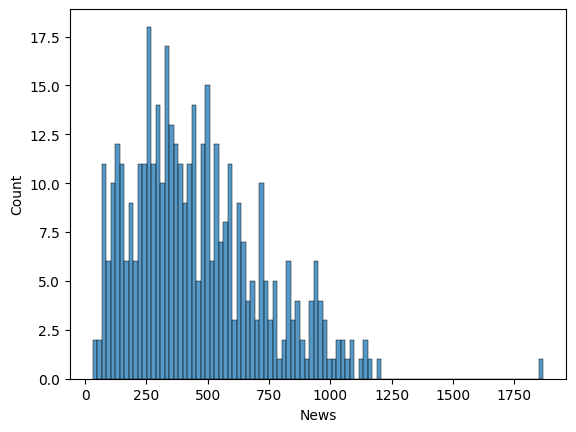

In [15]:
sns.histplot(data['News'].str.count(r'\S+'),bins=100)

Most news articles are around 400 to 700 words long, which should be sufficient to capture meaningful context for sentiment prediction.

Distribution of Stock Price Features (Open, Close, High, Low)

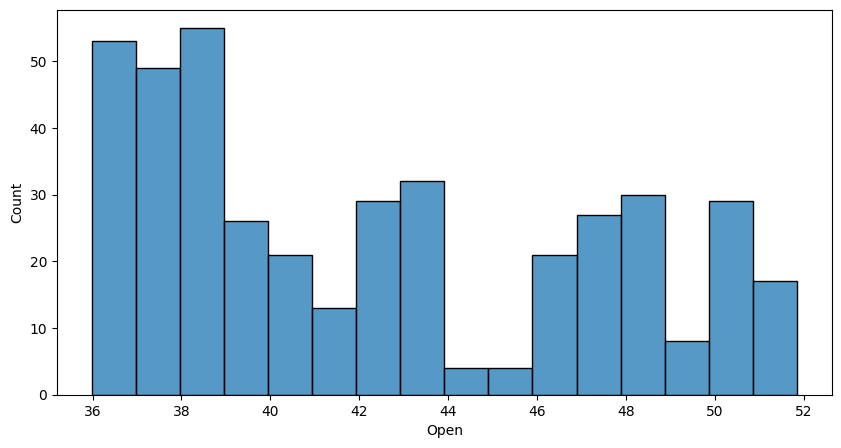

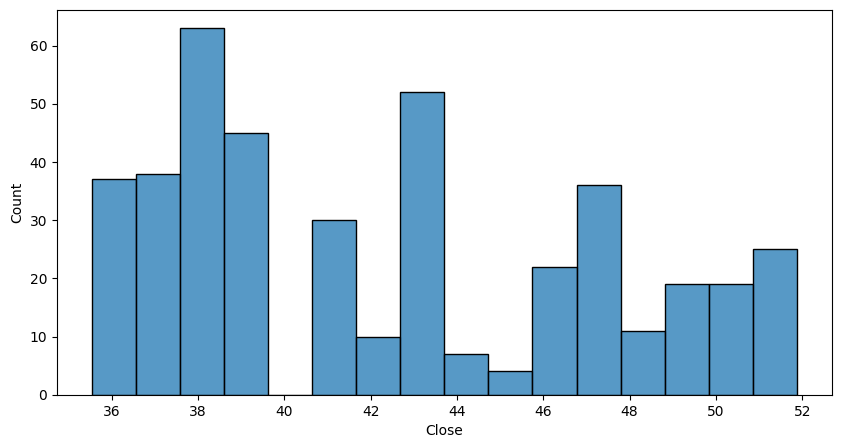

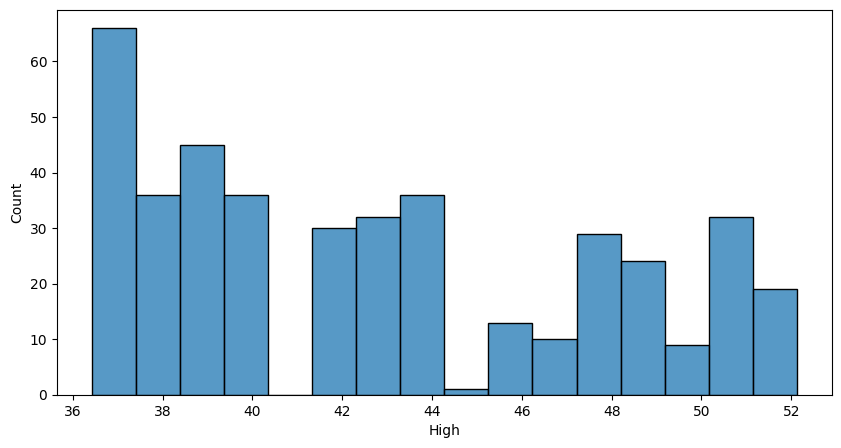

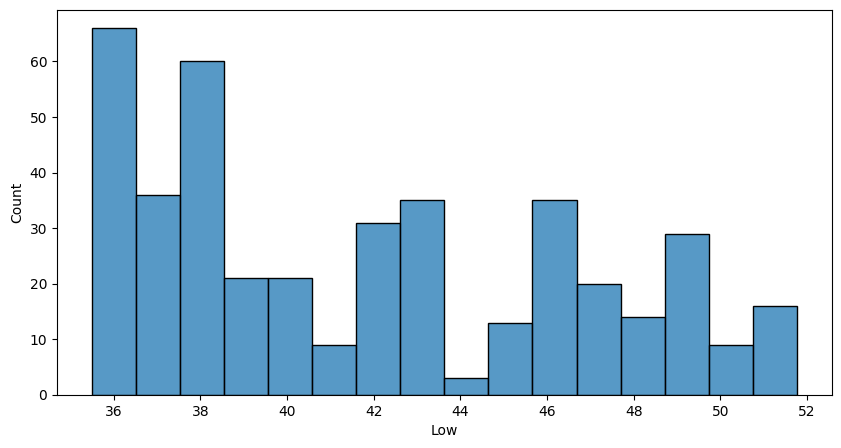

In [16]:
x_col= ['Open','Close','High','Low']
for col in x_col:
  plt.figure(figsize=(10, 5))
  sns.histplot(data[col], bins=16)

The histograms show that the Open and Close prices are not evenly distributed, with some price ranges appearing more frequently than others. This is likely because the dataset contains multiple news entries for the same date, which increases the number of repeated price values and creates higher counts in certain bins. To understand this relationship better, we will perform bivariate analysis between news sentiment and stock prices.

In [17]:
cat_columns = ['Label','Date']
num_columns = ['Open','Close','High','Low','Volume']

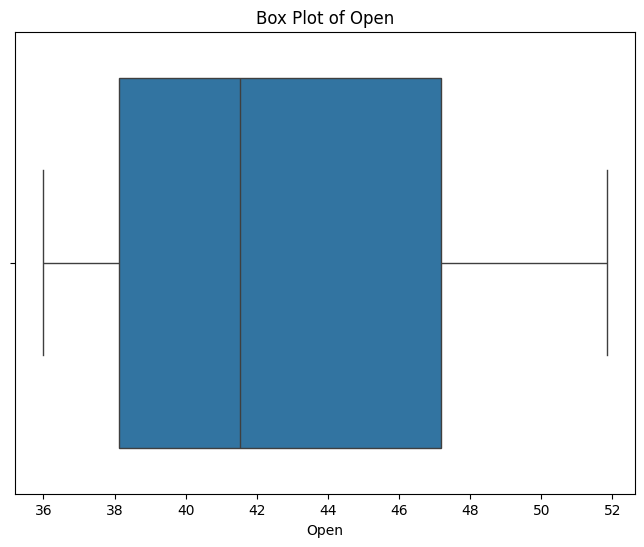

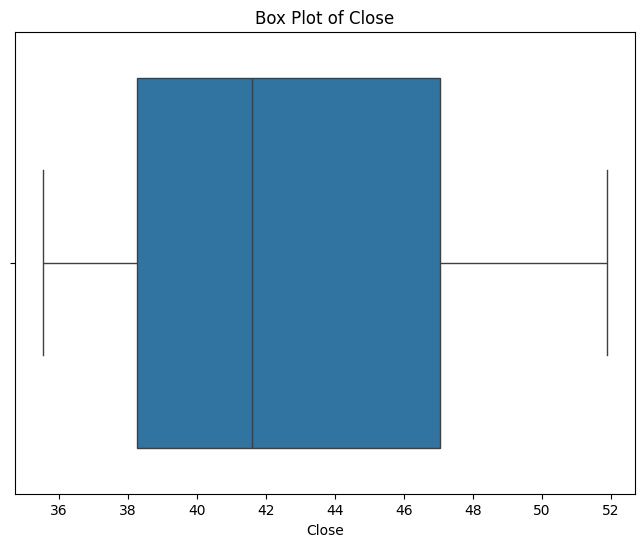

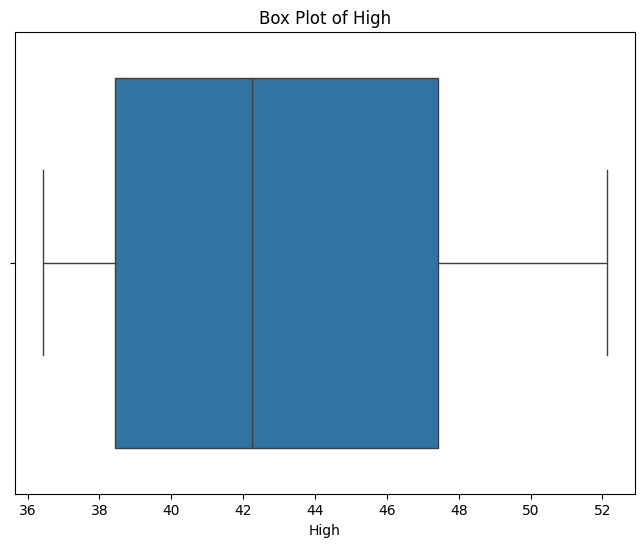

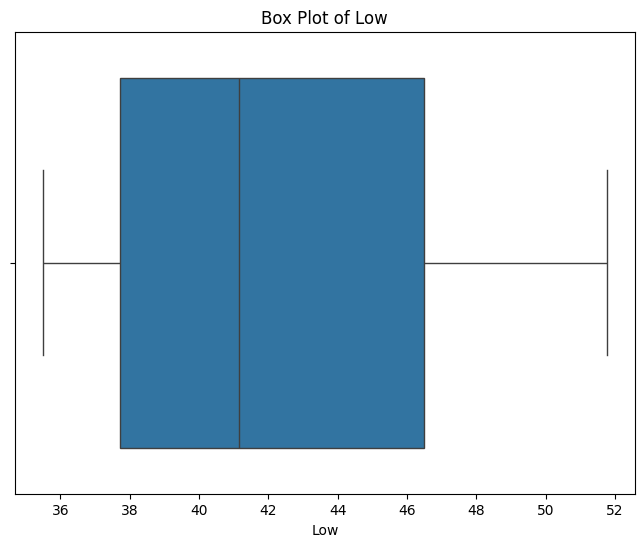

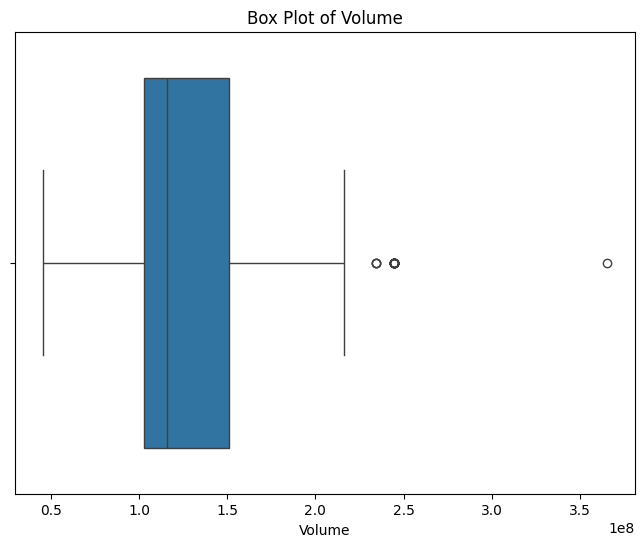

In [18]:
# This code iterates through all numerical columns in the dataset and generates a box plot for each one to visualize the distribution and detect outliers.
for column in num_columns:
  plt.figure(figsize=(8, 6))
  sns.boxplot(x=data[column])
  plt.title(f'Box Plot of {column}')
  plt.xlabel(column)
  plt.show()


The box plots show that the prices are fairly well distributed, with most values lying within a moderate range. The median for all columns indicat stable central price level. There are no major outliers visible in price columns, suggesting the price data is clean. Overall, the spread of values indicates normal market variation rather than extreme price fluctuations.


We observe some outliers in the Volume column, indicating that trading activity was significantly higher on certain days.

### **Bivariate Analysis**

**Visualize the Label vs Prices box plot.**

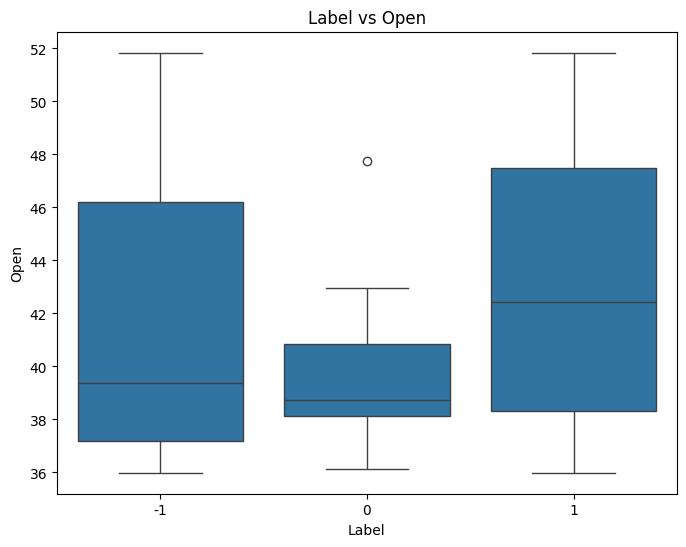

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Label', y='Open', data=data)
plt.title('Label vs Open')
plt.xlabel('Label')
plt.ylabel('Open')
plt.show()

The box plot suggests that the Open price tends to be higher for positive sentiment compared to negative sentiment. However, since the dataset does not include the news publication time, we cannot confirm whether the sentiment actually influenced the Open price.

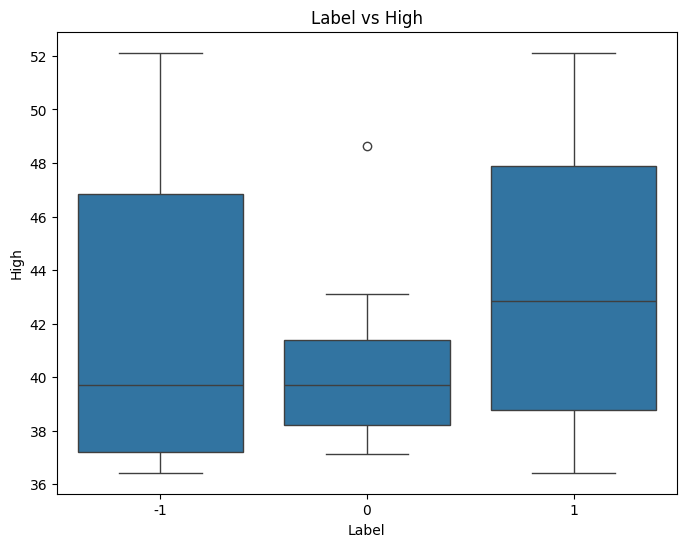

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Label', y='High', data=data)
plt.title('Label vs High')
plt.xlabel('Label')
plt.ylabel('High')
plt.show()

The mean daily high is higher for positive news sentiment. While this relationship may depend on timing, the results suggest that positive sentiment is generally associated with higher highs and opening prices.

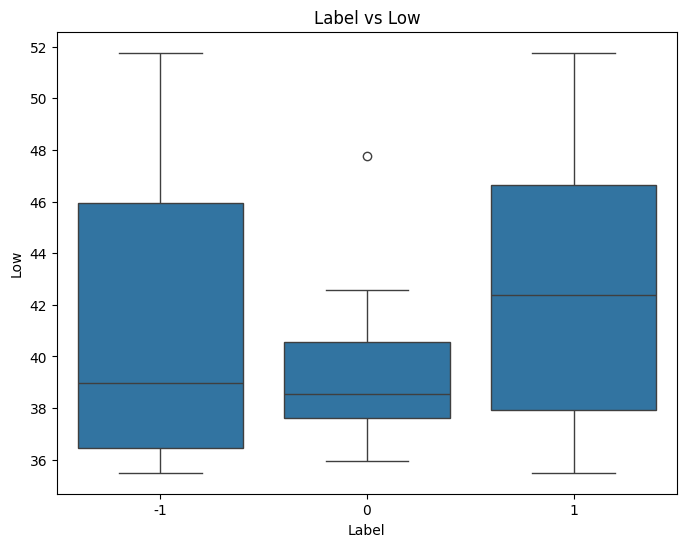

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Label', y='Low', data=data)
plt.title('Label vs Low')
plt.xlabel('Label')
plt.ylabel('Low')
plt.show()

We observe a higher mean for daily lows on days with positive news sentiment. However, since both the news timing and the time at which the low occurred are unknown, this relationship cannot be confirmed with certainty. Overall, the data suggests that positive sentiment is generally associated with higher open, high, and low prices

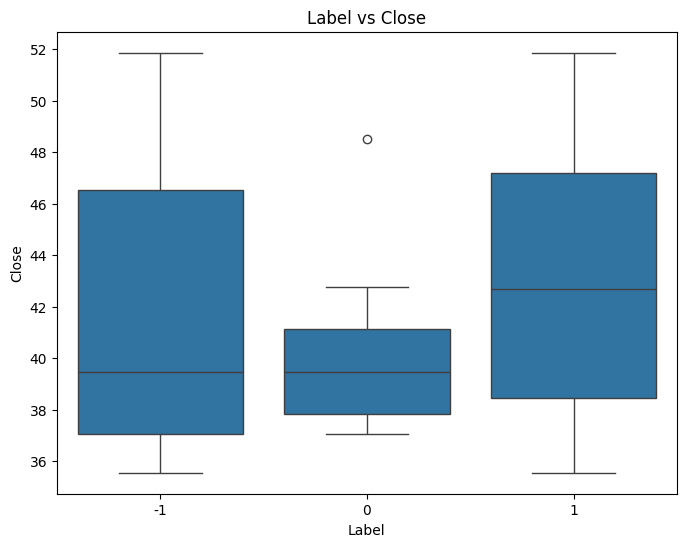

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Label', y='Close', data=data)
plt.title('Label vs Close')
plt.xlabel('Label')
plt.ylabel('Close')
plt.show()

We observe a higher average daily Close price for positive news. Although this relationship may depend on the time the news was published, overall the data suggests that positive sentiment is associated with higher Open, High, Low, and Close prices.


**Label vs Volume analysis**




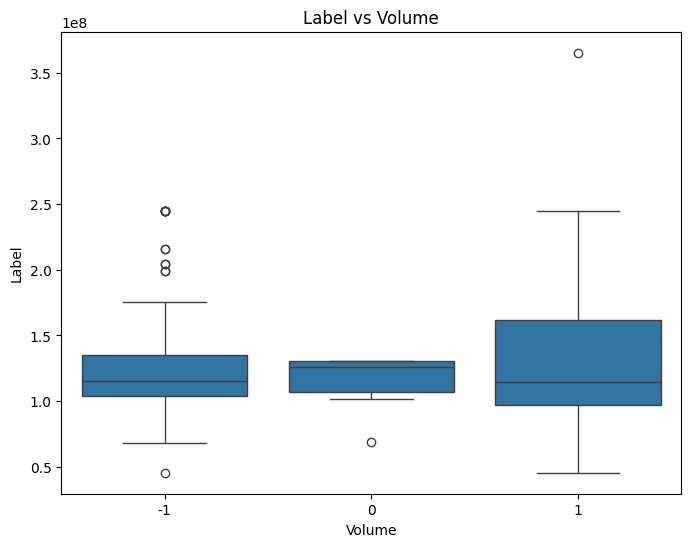

In [23]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Label', y='Volume', data=data)
plt.title('Label vs Volume')
plt.xlabel('Volume')
plt.ylabel('Label')
plt.show()

The median trading volume is nearly the same across all sentiment labels, suggesting volume is not strongly affected by sentiment. However, the positive label shows slightly higher variability with a few extreme high volume outliers.

Checking correlation between prices, volume and Label

In [24]:
data_new = data[['Open', 'High', 'Low', 'Close', 'Volume', 'Label']]
data_new.corr()

,Open,High,Low,Close,Volume,Label
Open,1.000000,0.997830,0.997989,0.994757,-0.112357,0.129252
High,0.997830,1.000000,0.997515,0.997773,-0.096856,0.131658
Low,0.997989,0.997515,1.000000,0.997240,-0.133034,0.134468
Close,0.994757,0.997773,0.997240,1.000000,-0.103173,0.139278
Volume,-0.112357,-0.096856,-0.133034,-0.103173,1.000000,0.055345
Label,0.129252,0.131658,0.134468,0.139278,0.055345,1.000000


The price features (Open, High, Low, Close) are highly correlated with each other, indicating they move together and contain similar information. In contrast, the correlation between the sentiment label and all price/volume features is very low (< 0.2), suggesting sentiment has little direct linear relationship with market prices in this dataset. Hence we can drop Open, High, Low, Close and Volume from Sentiment Analysis




Scatter plot date vs open

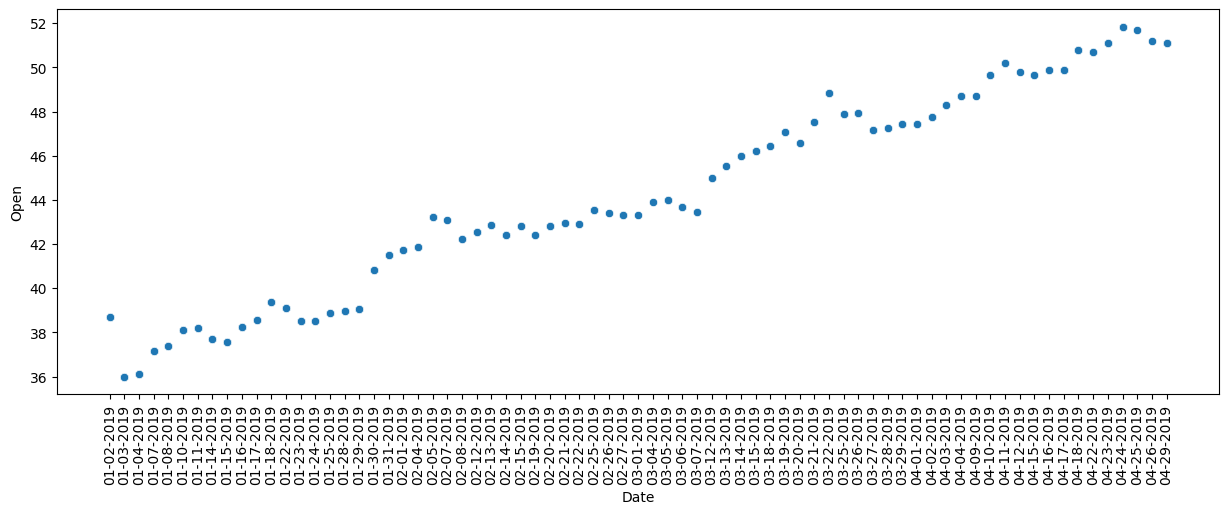

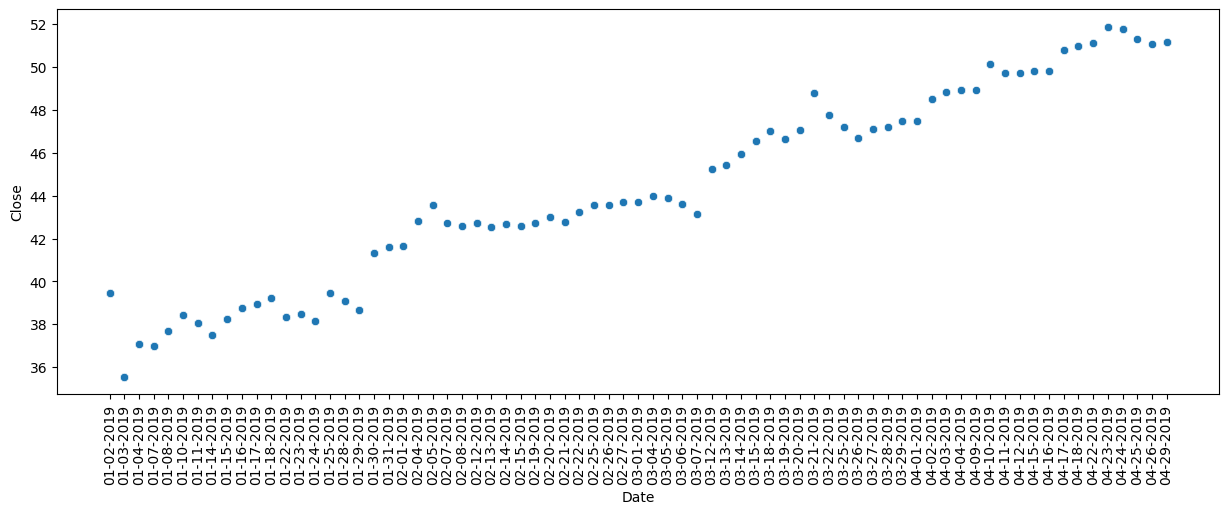

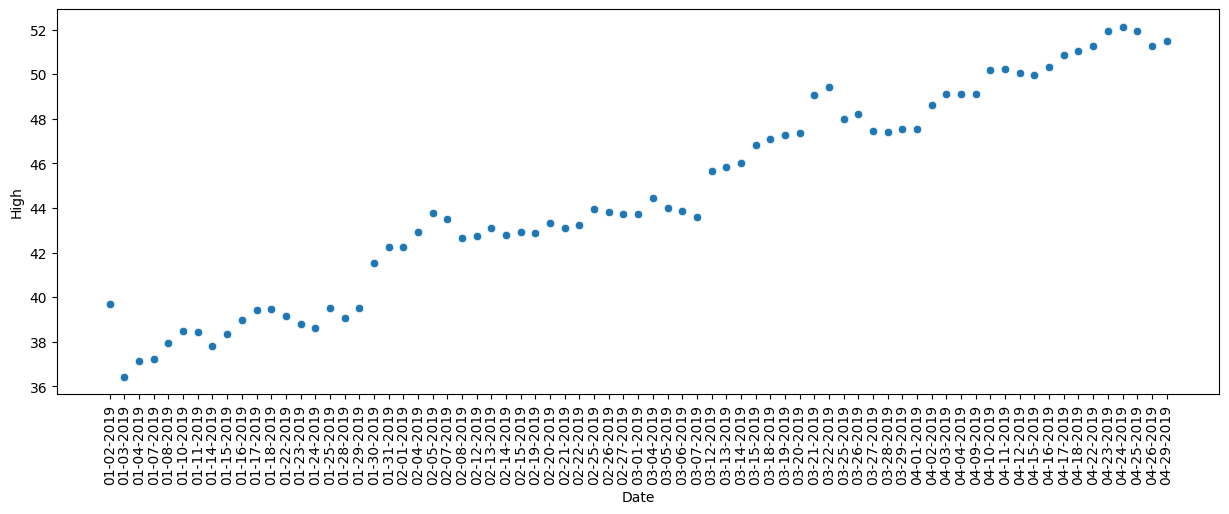

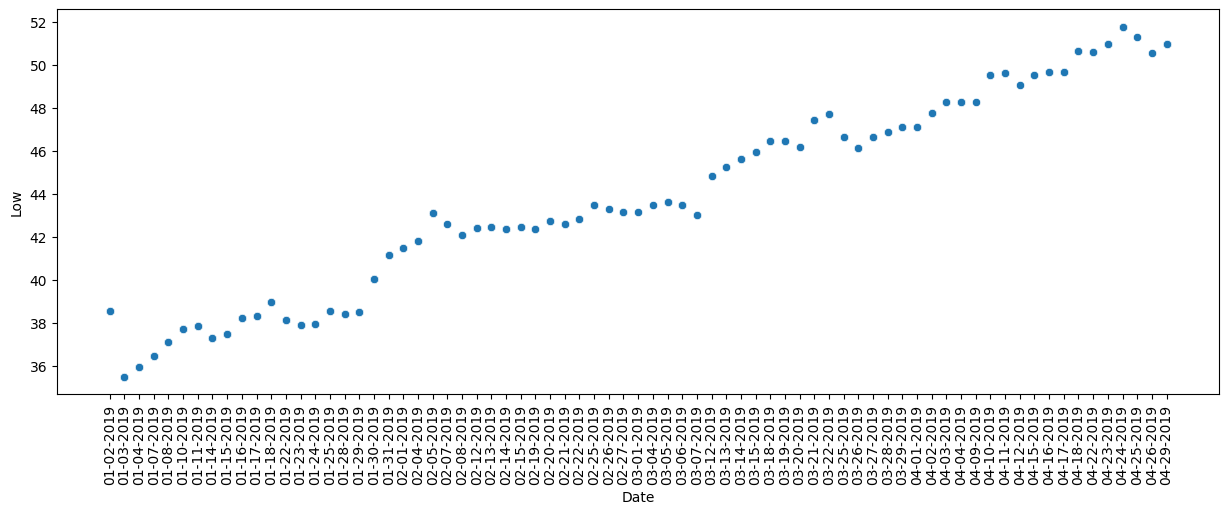

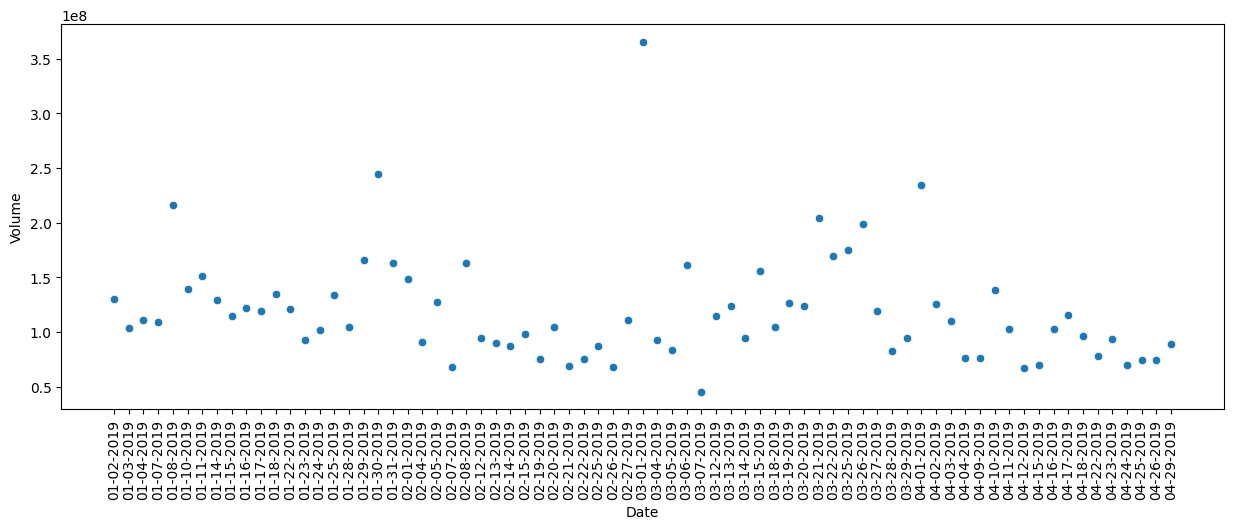

In [25]:
num_columns = ['Open','Close','High','Low','Volume']
for col in num_columns:
  plt.figure(figsize=(15, 5))
  plt.xticks(rotation=90)
  sns.scatterplot(
      data=data,
      x='Date',
      y=col
  )


Over the 73 days covered in the dataset, the stock price shows an overall upward trend. Trading volume remains relatively consistent across most dates. This upward movement may also be influenced by the higher number of positive sentiment news articles during the same period.

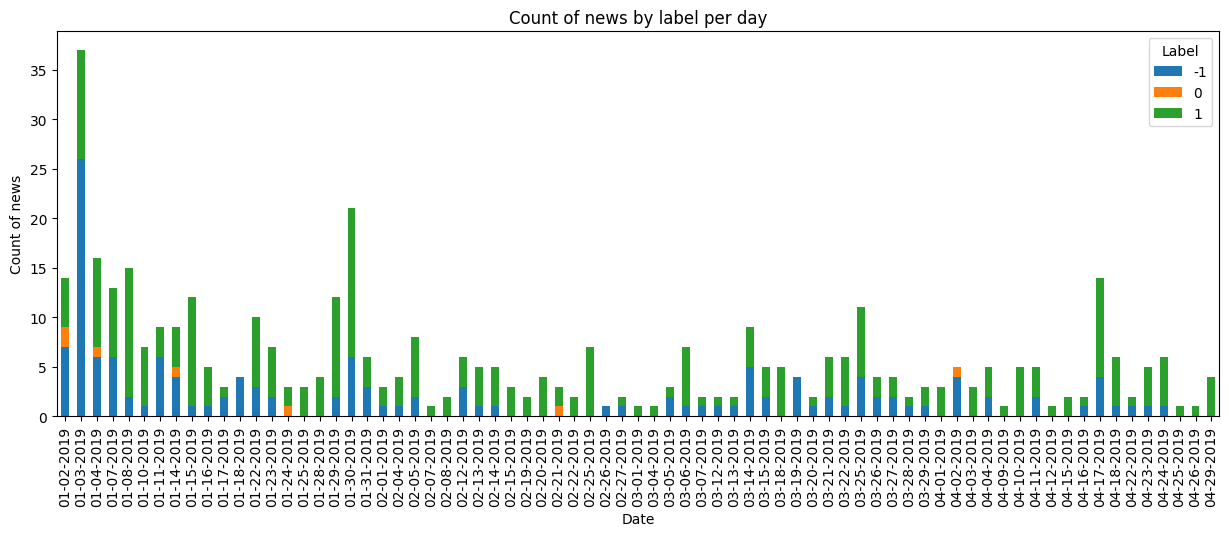

In [26]:
label_by_date = data.groupby('Date')['Label'].value_counts(normalize=False).unstack()

# Create the stacked bar chart
label_by_date.plot(kind='bar', stacked=True, figsize=(15, 5))
plt.title('Count of news by label per day')
plt.xlabel('Date')
plt.ylabel('Count of news')
plt.xticks(rotation=90)
plt.legend(title='Label')
plt.show()



On most days, the dataset contains more positive news than negative or neutral. Neutral news instances are very few and are sparsely distributed across the dates.

## **Data Preprocessing**

Based on the EDA, the price, and volume features do not show a strong relationship with the sentiment label. Therefore, we can drop these columns and rely only on the news content for sentiment classification.

In [27]:
data = data.drop(['Open', 'High', 'Low', 'Close', 'Volume'], axis=1)
data.head(5)

,Date,News,Label
0,01-02-2019,The dollar minutes ago tumbled to 106 67 from above 109 a few trades earlier It s since bounced a hair to 107 16 FXY 3 6 after hoursAlongside money poured into U S government paper with the 10 year Treasury yield sliding a few more basis points to 2 61 TLT 0 7 after hour Both moves come following Apple NASDAQ AAPL s revenue warning which sent its shares and U S stock index futures into the red Apple s currently off 7 5 and the QQQs 2 2 ETFs TLT TBT TMV FXY YCS TBF EDV TMF TTT ZROZ VGLT OTC JYN TLH UBT SPTL YCL DLBS VUSTX TYBS DLBL OLD DJPY OPER UJPYNow read,1
1,01-02-2019,By Wayne Cole and Swati Pandey SYDNEY Reuters The Japanese yen soared in early Asian trading on Thursday as the break of key technical levels triggered massive stop loss sales of the U S and Australian dollars in very thin markets The dollar collapsed to as low as 105 25 yen on Reuters dealing a drop of 3 2 percent from the opening 108 76 and the lowest reading since March 2018 It was last trading around 107 50 yen Analysts said the rot began when tech bellwether Apple Inc O AAPL shocked investors by cutting its earnings guidance citing sluggish iPhone sales in China The news sent U S stock futures sliding and sparked a rush of funds to safe haven bonds With risk aversion high the safe haven yen was propelled through major technical levels and triggered massive stop loss flows from investors who have been short of the yen for months The move was exacerbated by a dearth of liquidity with Japan still on holiday after the New Year and by automated algorithmic trades which are carried out by computers in micro seconds Most major currencies simply collapsed against the yen in a matter of seconds Looks like we had a flash crash said Ray Attrill head of FX strategy at National Australia Bank One theory is that may be Japanese retail FX players are forcing out of AUDJPY which is creating a liquidity vacuum he added This is a market dislocation rather than a fundamental event The Australian dollar tumbled to as low as 72 26 yen AUDJPY D3 on Reuters dealing a level not seen since late 2011 having started around 75 21 It was last changing hands at 73 72 yen The Aussie in turn sank against the U S dollar to as far as 0 6715 the lowest since March 2009 having started around 0 6984 It was last trading at 0 6888 \nOther currencies smashed against the yen included the euro sterling and the Turkish lira,-1
2,01-02-2019,By Stephen Culp NEW YORK Reuters Wall Street edged higher on Wednesday after stumbling out of the starting gate on the first trading day of 2019 while fears of a global economic slowdown were exacerbated after Apple cut its holiday quarter revenue forecast Apple O AAPL dropped 8 percent in extended trading late in the day after the iPhone maker slashed its outlook for the December quarter blaming weak demand in China Shares of Apple s suppliers also fell and S P 500 futures dropped 1 3 percent signaling that Wednesday s modest advance could unwind when the market reopens on Thursday To see Apple s sales drop off this much says something about the Chinese economy said Tim Ghriskey chief investment strategist at Inverness Counsel in New York Any company that does business in China will feel the impact of this Stocks had started the session lower after separate reports showed a deceleration in factory activity in China and the euro zone indicating the ongoing trade dispute between the United States and China was taking a toll on global manufacturing Energy SPNY stocks led the S P 500 s advance and the sector was the index s biggest percentage gainer buoyed by a 2 4 percent jump in crude prices The group was the worst performing S P sector in 2018 Gains were offset by healthcare SPXHC and so called defensive sectors such as real estate utilities SPLRCU and consumer staples SPLRCS Healthcare companies provided the biggest drag on the S P 500 and the Dow The Dow Jones Industrial Average DJI rose 18 78 points or 0 08 percent to 23 346 24 

Since the labels are originally -1, 0, and 1, but a softmax classifier requires non-negative class indices, we add 1 to each label. This maps the classes as follows:

0 → Negative

1 → Neutral

2 → Positive

In [28]:
data.Label = data.Label +1

We split the data into training and testing sets based on the date to preserve the real-world timeline. This ensures the model is not trained on future news, preventing data leakage and giving a more realistic evaluation.

In [29]:
# Define the target variable (y) and the features (X)
y = data['Label']
X = data.drop('Label', axis=1)

data_2 = data.sort_values("Date")
split = int(len(data_2)*0.8)

X_train = data_2.iloc[:split]
X_test  = data_2.iloc[split:]
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = data_2.iloc[:split]['Label']
y_test = data_2.iloc[split:]['Label']

# Print the shapes of the resulting sets to verify the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (334, 3)
X_test shape: (84, 3)
y_train shape: (334,)
y_test shape: (84,)


In [30]:
X_train.head()

,Date,News,Label
0,01-02-2019,The dollar minutes ago tumbled to 106 67 from above 109 a few trades earlier It s since bounced a hair to 107 16 FXY 3 6 after hoursAlongside money poured into U S government paper with the 10 year Treasury yield sliding a few more basis points to 2 61 TLT 0 7 after hour Both moves come following Apple NASDAQ AAPL s revenue warning which sent its shares and U S stock index futures into the red Apple s currently off 7 5 and the QQQs 2 2 ETFs TLT TBT TMV FXY YCS TBF EDV TMF TTT ZROZ VGLT OTC JYN TLH UBT SPTL YCL DLBS VUSTX TYBS DLBL OLD DJPY OPER UJPYNow read,2
1,01-02-2019,By Kate Duguid NEW YORK Reuters Yields on long dated U S Treasury securities fell to their lowest in nearly a year on Wednesday on concerns about the health of the global economy a worry exacerbated late in the day when Apple Inc O AAPL cut its sales outlook and sent U S equity index futures tumbling Throughout the first trading day of 2019 investors piled into safe haven investments like longer dated Treasuries and German bunds after weak data out of China and Europe was reported overnight and a partial shutdown of the U S government continued Yields on benchmark 10 year notes US10YT RR fell to their lowest since late last January They hit a fresh 11 month low near 2 62 percent late in the day when Apple announced sales would fall well short of previous forecasts largely because of a slowdown in demand for its iPhones in China China s economy was already of central concern after a measure of its manufacturing activity shrank for the first time in 19 months in December hit by the Chinese U S trade war with the weakness spilling over to other Asian economies Chinese PMI came in weaker than expected and gave a risk off tone to global markets There are now mounting concerns about global growth said Justin Lederer Treasury analyst and trader at Cantor Fitzgerald The 10 year note yield was last at 2 63 percent breaching the key technical level of 2 64 percent Ten year yields fell nearly 6 basis points on the day their largest one day fall in a month Other safe haven investments also benefited in price from the flight to quality The benchmark 10 year German government bond yield DE10YT RR was down 7 basis points last at 0 17 percent While U S stocks eked out modest gains on Wednesday to start the new year after their poorest yearly showing in a decade in 2018 Apple s weak sales forecast after Wall Street closed sent equity index futures sharply lower bringing in further support for Treasuries The grim readings from Asia s and Europe s purchasing manager surveys came ahead of the closely watched U S manufacturing survey on Thursday payrolls data on Friday and the U S earnings season later this month which is expected to show corporate profit shrank in the October December quarter Oil prices rose about 4 percent in choppy trading on Wednesday supported by gains in U S equity markets but concerns remained about rising crude production and weakening global economic growth The yield on the two year Treasury note US2YT RR was supported by the rise in oil prices last up about half a basis point to 2 504 percent With the sharp drop in long dated yields the yield curve flattened to a spread of 15 2 basis points between the two and 10 year note yields \nA section of the yield curve sank deeper into inversion with the yield on 1 year bills US1YT RR now exceeding those on all securities through the 7 year maturity US7YT RR,0
2,01-02-2019,Apple s NASDAQ AAPL Tim Cook appears on CNBC to discuss the company s Q1 warning and reiterates that US China trade tensions played a role Cook There are a lot of things we can do to turn our business around both in China and more generally Cook says he isn t discussing iPhone unit sales due to the wide range of pricing but that doesn t mean Apple won t comment on unit sales again Note that the company announced plans to end unit sales reporting during the last quarterly report Services revenue is forecasted at ov

## **Word Embeddings**

Here, we generate text embeddings using both Word2Vec and Sentence Transformer models. Sentence Transformers are expected to capture richer contextual meaning because they produce embeddings at the sentence level, representing the overall semantics of the entire sentence rather than individual words.

#### **Word2Vec**

In [31]:
#Creating the complete word list
words_list = [item.split(" ") for item in data['News'].values]


In [32]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [33]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 14577


We have 14,539 unique words in our vocabulary.

In [34]:
#Visualise embedding for word import
model_W2V.wv["import"]

array([-0.00675046,  0.12365182, -0.01216732, -0.00936136, -0.00814299,
       -0.11477163,  0.04994319,  0.22859755, -0.005585  , -0.05600594,
        0.04294575, -0.04097666,  0.01064031,  0.02831098, -0.02702252,
       -0.06745205,  0.09615074,  0.00158888,  0.00373864, -0.09831912,
       -0.02213948, -0.04949345,  0.13031982,  0.07101268,  0.04921469,
       -0.03279423, -0.10774798, -0.01665957, -0.02187701, -0.10207179,
        0.01095343, -0.0317897 , -0.02221743, -0.02405774,  0.01131846,
        0.03254569,  0.00034275, -0.08031889, -0.05817573,  0.00183966,
       -0.06872027,  0.00038939, -0.01495676, -0.0158982 ,  0.01699352,
        0.06194581, -0.00519908,  0.03833232, -0.03532637,  0.08371605,
       -0.02082153,  0.03587521, -0.10297432,  0.01882429, -0.02236165,
        0.10834181,  0.10497063,  0.00254517,  0.04477037, -0.00849703,
        0.01888585,  0.03941941,  0.03124356, -0.03942559, -0.04380387,
        0.0794322 ,  0.00256632,  0.05434162, -0.08496671,  0.01

In [35]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [36]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")
    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]
    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])
    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)
    return feature_vector

Converting each news article into a 300 dimensional vector by averaging the vectors of all the words in the article.

In [37]:
X_train_df_Word2Vec = pd.DataFrame(X_train['News'].copy().apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_train_df_Word2Vec.head()

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,-0.035842,0.390014,-0.075840,-0.064058,-0.057781,-0.294800,0.241352,0.744273,-0.034975,-0.224679,...,0.063791,0.480919,0.178099,0.034693,0.397489,0.369584,0.042867,-0.001016,0.320189,-0.238181
1,-0.056436,0.514266,-0.064381,-0.042080,-0.053805,-0.410509,0.231967,0.974800,-0.029224,-0.236420,...,0.091944,0.572527,0.157980,-0.003813,0.487914,0.425771,0.052743,0.068787,0.418532,-0.289539
2,-0.011527,0.435324,0.007076,-0.029227,-0.017261,-0.449809,0.270157,0.827222,0.027104,-0.204978,...,0.034695,0.520493,0.161804,0.061027,0.455536,0.382790,0.057180,0.058712,0.400101,-0.234335
3,-0.048580,0.456664,-0.126022,-0.080153,-0.099047,-0.316635,0.335206,0.890188,-0.041108,-0.282501,...,0.079823,0.580187,0.233519,0.060437,0.496753,0.467638,0.064237,-0.049185,0.354836,-0.289733
4,-0.020595,0.466965,-0.096371,-0.141560,-0.106303,-0.370993,0.481049,0.895602,-0.027511,-0.388328,...,0.045682,0.664374,0.350533,0.158854,0.551368,0.558342,0.069091,-0.146839,0.364704,-0.303024


In [38]:
X_test_df_Word2Vec = pd.DataFrame(X_test['News'].copy().apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_df_Word2Vec.head()

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,0.032918,0.455214,0.020631,-0.072195,-0.000151,-0.540732,0.258368,0.871828,-0.003011,-0.259569,...,0.018337,0.599052,0.237966,0.094601,0.476574,0.425039,0.000440,0.068116,0.479988,-0.284312
1,-0.040759,0.476083,-0.079989,-0.065146,-0.083032,-0.379660,0.360715,0.916992,-0.028590,-0.279405,...,0.066566,0.596067,0.240848,0.073243,0.520069,0.471138,0.080294,-0.030788,0.382199,-0.289396
2,-0.029658,0.486174,-0.082818,-0.076690,-0.055425,-0.399835,0.232824,0.925471,-0.057958,-0.267260,...,0.082498,0.586665,0.211157,0.024944,0.470546,0.439432,0.019525,0.039886,0.420883,-0.308426
3,-0.010006,0.428878,0.011629,-0.007431,-0.003803,-0.446361,0.237095,0.813776,0.016669,-0.168100,...,0.035517,0.498962,0.134803,0.044946,0.442814,0.347676,0.056490,0.085267,0.406023,-0.232061
4,-0.035899,0.495865,-0.142710,-0.104853,-0.103123,-0.349895,0.372122,0.967201,-0.087739,-0.326586,...,0.085015,0.668617,0.301062,0.076086,0.542716,0.520776,0.056637,-0.056991,0.407885,-0.343451


### **Sentence Transformer**

Here we are using all-MiniLM-L6-v2 for generating sentence embedding as all-MiniLM-L6-v2 is a lightweight Sentence Transformer model that generates high-quality 384-dimensional sentence embeddings efficiently while preserving strong semantic understanding.

In [39]:
#Loading the Sentence transformer model
model_st = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [40]:
#Encoding the news as vectors using sentance transformer. This should help us capture relationship in words by using emcoder.
X_train_st_embedding_matrix = model_st.encode(X_train['News'], show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [41]:
X_test_st_embedding_matrix = model_st.encode(X_test['News'], show_progress_bar=True)

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

In [42]:
X_train_st_embedding_matrix.shape

(334, 384)

In [43]:
X_test_st_embedding_matrix.shape

(84, 384)

Each sentence in the dataset is converted into a 384-dimensional embedding vector, which captures its semantic meaning and is used as input for the model.

## **Sentiment Analysis**

### **Model Evaluation Criterion**

We will use a confusion matrix to visualize the model’s performance, highlighting true positives, true negatives, false positives, and false negatives. For evaluation, we will use the F1-score as the primary metric because:

- The dataset is imbalanced, so accuracy alone would be misleading.

- F1-score balances precision (how many predicted positives are correct) and recall (how many actual positives are captured).

- High precision ensures fewer false positives, which is important as incorrect positive predictions can lead to huge financial loss.

- High recall ensures fewer false negatives, which is critical as missing positive cases means missed investment opportunity.

Accuracy is not a good metric here as we have high number of positive labels and high accuracy can be achieved by predicting everything as positive.

We will use the helper functions provided below to:
- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)

##### **Utility Functions**

In [44]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [45]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

In [46]:
#Defining the columns of the dataframe which are nothing but the hyper parameters and the metrics.
columns = ["Model Name","Estimators", "Max depth","# hidden layers","# neurons - hidden layer","activation function - hidden layer","# epochs","batch size","Train Accuracy","Test Accuracy","Train F1","Test F1", "Train Recall","Test Recall", "Train Precision","Test Precision" ]

#Creating a pandas dataframe.
results = pd.DataFrame(columns=columns)

This table stores the hyperparameters and evaluation metrics (Accuracy, F1, Precision, Recall) for both training and testing sets. It helps in identifying the best model and also highlights potential overfitting/Underfitting when training performance is much higher than testing performance.

### **Build Random Forest Models using different text embeddings**

### Random Forest on word2Vec Embedding - Model 1 (Word2Vec_RF_M1)

In [47]:
# Building the model
rf_word2vec = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_word2vec.fit(X_train_df_Word2Vec, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

In [48]:
# Predicting on train data
y_pred_train = rf_word2vec.predict(X_train_df_Word2Vec)

# Predicting on test data
y_pred_test = rf_word2vec.predict(X_test_df_Word2Vec)

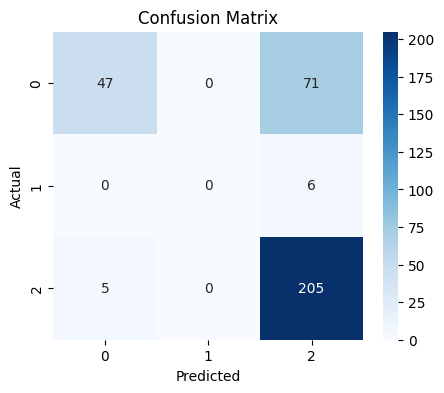

In [49]:
plot_confusion_matrix(y_train, y_pred_train)

We can observe that the model performs reasonably well on the training data, correctly predicting around 203 positive and about 50 negative news samples. However, it fails to predict any samples as neutral, indicating that the model is biased toward the positive and negative classes and is not learning the neutral category effectively.

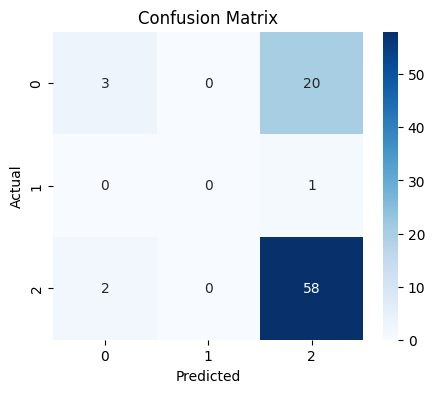

In [50]:
plot_confusion_matrix(y_test, y_pred_test)

The model appears to be biased toward predicting news as Positive. As a result, it produces a relatively high number of false positives, meaning several non-positive news samples are incorrectly classified as Positive.

In [51]:
train_accuracy_Word2Vec_RF = accuracy_score(y_train,y_pred_train)
print("The accuracy on the training set is: ",train_accuracy_Word2Vec_RF)
test_accuracy_Word2Vec_RF = accuracy_score(y_test,y_pred_test)
print("The accuracy on the test set is: ",test_accuracy_Word2Vec_RF)
train_f1_score_Word2Vec_RF = f1_score(y_train,y_pred_train, average='weighted')
print("The F1 score on the training set is: ",train_f1_score_Word2Vec_RF)
test_f1_score_Word2Vec_RF = f1_score(y_test,y_pred_test, average='weighted')
print("The F1 score on the test set is: ",test_f1_score_Word2Vec_RF)


The accuracy on the training set is:  0.7544910179640718
The accuracy on the test set is:  0.7261904761904762
The F1 score on the training set is:  0.7193025713279324
The F1 score on the test set is:  0.6547680223168404


The model has a low F1-score because it predicts most of the news as Positive, which leads to poor performance on the other classes.

In [52]:
#Storing model performance data for comparison
word2Vec_rf_train_performance = model_performance_classification_sklearn(y_train,y_pred_train)
word2Vec_rf_test_performance = model_performance_classification_sklearn(y_test,y_pred_test)
results.loc[0] = ["Word2Vec_RF_M1",100,3, "-","-","-","-","-",word2Vec_rf_train_performance.Accuracy[0],word2Vec_rf_test_performance.Accuracy[0],word2Vec_rf_train_performance.F1[0],word2Vec_rf_test_performance.F1[0],word2Vec_rf_train_performance.Recall[0],word2Vec_rf_test_performance.Recall[0],word2Vec_rf_train_performance.Precision[0],word2Vec_rf_test_performance.Precision[0]]


**Conclusion:** The model is not performing well, as both the training and testing F1 scores are low. To improve performance, we will increase the model depth to add more complexity, allowing it to capture richer patterns in the data.

### Random Forest on word2Vec Embedding - Model 2 (Word2Vec_RF_M2)

In [53]:
# Building the model
rf_word2vec = RandomForestClassifier(n_estimators = 100, max_depth = 4, random_state = 42)

# Fitting on train data
rf_word2vec.fit(X_train_df_Word2Vec, y_train)

RandomForestClassifier(max_depth=4, random_state=42)

In [54]:
# Predicting on train data
y_pred_train = rf_word2vec.predict(X_train_df_Word2Vec)

# Predicting on test data
y_pred_test = rf_word2vec.predict(X_test_df_Word2Vec)

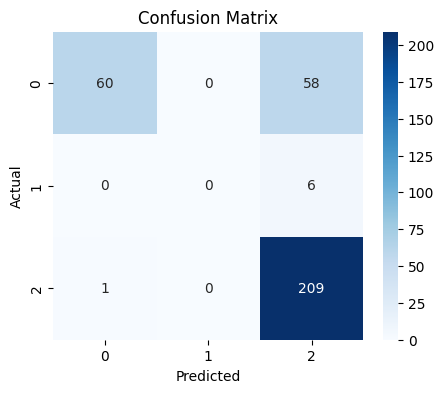

In [55]:
plot_confusion_matrix(y_train, y_pred_train)

The model performs better on the training data, correctly predicting around 205 positive and about 60 negative news samples. This suggests that the model is capturing more patterns related to the negative classes in the training set.

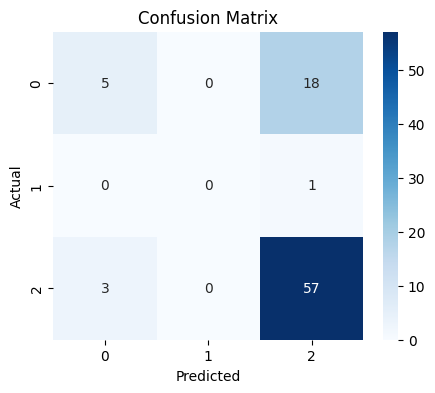

In [56]:
plot_confusion_matrix(y_test, y_pred_test)

We can see that the model is still biased toward predicting news as Positive, which leads to a higher number of false positives.

In [57]:
train_accuracy_Word2Vec_RF = accuracy_score(y_train,y_pred_train)
print("The accuracy on the training set is: ",train_accuracy_Word2Vec_RF)
test_accuracy_Word2Vec_RF = accuracy_score(y_test,y_pred_test)
print("The accuracy on the test set is: ",test_accuracy_Word2Vec_RF)
train_f1_score_Word2Vec_RF = f1_score(y_train,y_pred_train, average='weighted')
print("The F1 score on the training set is: ",train_f1_score_Word2Vec_RF)
test_f1_score_Word2Vec_RF = f1_score(y_test,y_pred_test, average='weighted')
print("The F1 score on the test set is: ",test_f1_score_Word2Vec_RF)


The accuracy on the training set is:  0.8053892215568862
The accuracy on the test set is:  0.7380952380952381
The F1 score on the training set is:  0.7809738792999379
The F1 score on the test set is:  0.6870651486401013


The model shows a significant improvement in training accuracy and F1 score, but only about a 1–2% increase in accuracy and F1 score on the test data. This indicates that the model is starting to overfit as the depth increases.

In [58]:
#Storing model performance data for comparison
word2Vec_rf_train_performance = model_performance_classification_sklearn(y_train,y_pred_train)
word2Vec_rf_test_performance = model_performance_classification_sklearn(y_test,y_pred_test)
results.loc[1] = ["Word2Vec_RF_M2",100,4, "-","-","-","-","-",word2Vec_rf_train_performance.Accuracy[0],word2Vec_rf_test_performance.Accuracy[0],word2Vec_rf_train_performance.F1[0],word2Vec_rf_test_performance.F1[0],word2Vec_rf_train_performance.Recall[0],word2Vec_rf_test_performance.Recall[0],word2Vec_rf_train_performance.Precision[0],word2Vec_rf_test_performance.Precision[0]]

**Conclusion:** We did not observe any significant improvement in the model’s performance after tuning the tree depth. Therefore, we proceed to test a Random Forest model using Sentence Transformer embeddings.

### Random Forest on Sentence Transformer Model 1 (SentanceTransformer_RF_M1)

In [59]:
# Building the model
rf_transformer = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train_st_embedding_matrix, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

In [60]:
# Predicting on train data
y_pred_train = rf_transformer.predict(X_train_st_embedding_matrix)

# Predicting on test data
y_pred_test = rf_transformer.predict(X_test_st_embedding_matrix)

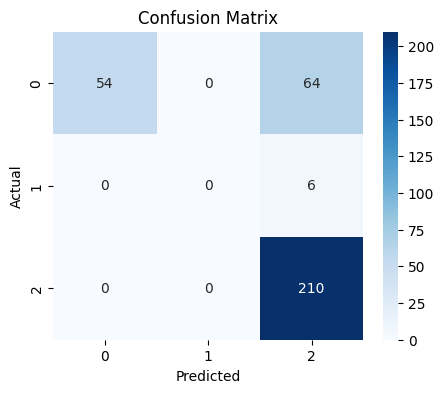

In [61]:
plot_confusion_matrix(y_train, y_pred_train)

On the training data, the model performs well, correctly predicting around 210 Positive samples and about 52 Negative samples. However, this strong performance may also indicate overfitting. To confirm this, we next plot the test confusion matrix to evaluate performance on unseen test data.


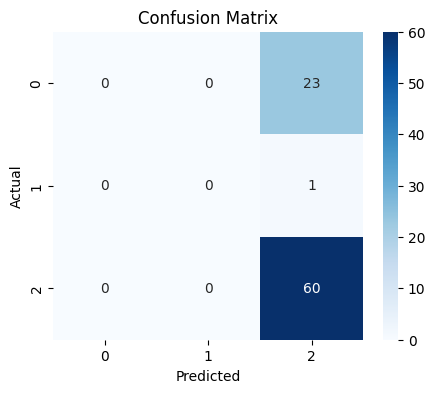

In [62]:
plot_confusion_matrix(y_test, y_pred_test)

From the confusion matrix, we can see that the model is predicting almost everything as Positive. This indicates a strong positive bias, meaning the model is not effectively learning to distinguish Negative and Neutral sentiment.

In [63]:
train_accuracy_transformer_RF = accuracy_score(y_train,y_pred_train)
print("The accuracy on the training set is: ",train_accuracy_transformer_RF)
test_accuracy_transformer_RF = accuracy_score(y_test,y_pred_test)
print("The accuracy on the test set is: ",test_accuracy_transformer_RF)
train_f1_score_transformer_RF = f1_score(y_train,y_pred_train, average='weighted')
print("The F1 score on the training set is: ",train_f1_score_transformer_RF)
test_f1_score_transformer_RF = f1_score(y_test,y_pred_test, average='weighted')
print("The F1 score on the test set is: ",test_f1_score_transformer_RF)

The accuracy on the training set is:  0.7904191616766467
The accuracy on the test set is:  0.7142857142857143
The F1 score on the training set is:  0.7607575546581257
The F1 score on the test set is:  0.5952380952380952


Although the model achieves higher accuracy and F1 score on the training data, the test performance drops to around 71% accuracy and about 59% F1 score. This indicates that the model does not generalize well to unseen test data.

In [64]:
#Storing model performance data for comparison
transformer_rf_train_performance = model_performance_classification_sklearn(y_train,y_pred_train)
transformer_rf_test_performance = model_performance_classification_sklearn(y_test,y_pred_test)
results.loc[2] = ["SentanceTransformer_RF_M1",100,4, "-","-","-","-","-",transformer_rf_train_performance.Accuracy[0],transformer_rf_test_performance.Accuracy[0],transformer_rf_train_performance.F1[0],transformer_rf_test_performance.F1[0],transformer_rf_train_performance.Recall[0],transformer_rf_test_performance.Recall[0],transformer_rf_train_performance.Precision[0],transformer_rf_test_performance.Precision[0]]

**Conculsion:** Since the model shows a strong bias toward predicting Positive and struggles to correctly capture Negative and Neutral sentiment, we further tune the hyperparameters to help the model learn more detailed patterns and improve class-wise performance.

### Random Forest on Sentence Transformer Model 2 (SentanceTransformer_RF_M2)

In [65]:
# Building the model
rf_transformer = RandomForestClassifier(n_estimators = 200, max_depth = 4, random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train_st_embedding_matrix, y_train)

RandomForestClassifier(max_depth=4, n_estimators=200, random_state=42)

In [66]:
# Predicting on train data
y_pred_train = rf_transformer.predict(X_train_st_embedding_matrix)

# Predicting on test data
y_pred_test = rf_transformer.predict(X_test_st_embedding_matrix)

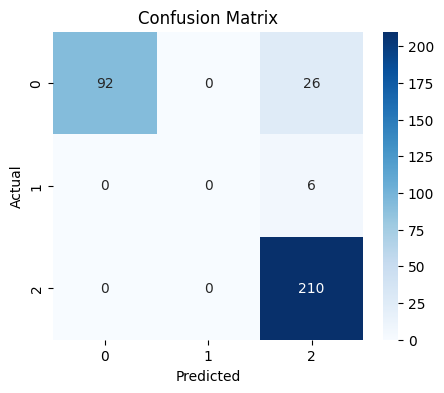

In [67]:
plot_confusion_matrix(y_train, y_pred_train)

On the training data, the model performs well, correctly predicting around 210 Positive samples and around 90 Negative samples. This suggests that the Random Forest model works better when combined with Sentence Transformer embeddings on the training set. However, this strong performance may also indicate overfitting. To confirm this, we next plot the test confusion matrix to evaluate the model's performance on unseen test data.

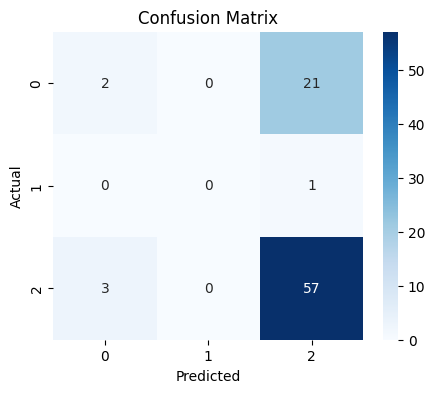

In [68]:
plot_confusion_matrix(y_test, y_pred_test)

The model predicts most news samples as Positive, which indicates a bias toward the Positive class and results in a high number of false positives.


In [69]:
train_accuracy_transformer_RF = accuracy_score(y_train,y_pred_train)
print("The accuracy on the training set is: ",train_accuracy_transformer_RF)
test_accuracy_transformer_RF = accuracy_score(y_test,y_pred_test)
print("The accuracy on the test set is: ",test_accuracy_transformer_RF)
train_f1_score_transformer_RF = f1_score(y_train,y_pred_train, average='weighted')
print("The F1 score on the training set is: ",train_f1_score_transformer_RF)
test_f1_score_transformer_RF = f1_score(y_test,y_pred_test, average='weighted')
print("The F1 score on the test set is: ",test_f1_score_transformer_RF)

The accuracy on the training set is:  0.9041916167664671
The accuracy on the test set is:  0.7023809523809523
The F1 score on the training set is:  0.8937820944709822
The F1 score on the test set is:  0.6249327068957079


The model achieves very high performance on the training data, with accuracy and F1 score close to 90%. However, on the test data, the accuracy drops to around 70% and the F1 score to about 62%, indicating that the model is overfitting.

In [70]:
#Storing model performance data for comparison
transformer_rf_train_performance = model_performance_classification_sklearn(y_train,y_pred_train)
transformer_rf_test_performance = model_performance_classification_sklearn(y_test,y_pred_test)
results.loc[3] = ["SentanceTransformer_RF_M2",200,4, "-","-","-","-","-",transformer_rf_train_performance.Accuracy[0],transformer_rf_test_performance.Accuracy[0],transformer_rf_train_performance.F1[0],transformer_rf_test_performance.F1[0],transformer_rf_train_performance.Recall[0],transformer_rf_test_performance.Recall[0],transformer_rf_train_performance.Precision[0],transformer_rf_test_performance.Precision[0]]


**Conculsion:** Random forest with sentence transformer is not giving better performance as it ends up overfitting the training data or having a very high positive bias. Next we try neural networks on each of the embeddings which can help capture more complex features.

### **Building Neural Network Models using different text embeddings**

### Neural Network on **Word2Vec - Model 1 (Word2Vec_NN_M1)**


In [71]:
#Setting the random state for consistent results across re-runs
keras.utils.set_random_seed(12)

In [72]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_df_Word2Vec.shape[1],)))
model.add(Dropout(0.3)) # Adding dropout to avoid overfitting
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))  # 3 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,443 (83.76 KB)

 Trainable params: 21,443 (83.76 KB)

 Non-trainable params: 0 (0.00 B)

Model have total 21,443 parameters.

In [73]:
# Fitting the model
history = model.fit(
    X_train_df_Word2Vec, y_train,
    validation_data=(X_test_df_Word2Vec, y_test),
    epochs=40,
    batch_size=64
)

Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.5329 - loss: 0.9622 - val_accuracy: 0.7143 - val_loss: 0.7255
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6257 - loss: 0.7951 - val_accuracy: 0.7143 - val_loss: 0.6640
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6287 - loss: 0.7666 - val_accuracy: 0.7143 - val_loss: 0.6724
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6168 - loss: 0.7453 - val_accuracy: 0.7143 - val_loss: 0.6900
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6347 - loss: 0.7345 - val_accuracy: 0.7143 - val_loss: 0.6676
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6108 - loss: 0.7489 - val_accuracy: 0.7143 - val_loss: 0.6568
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6257 - loss: 0.7369 - val_accuracy: 0.7143 - val_loss: 0.6693
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6228 - loss: 0.7379 - val_accuracy: 0.7143 - val_loss: 0.6712


In [74]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train_df_Word2Vec)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [75]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test_df_Word2Vec)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


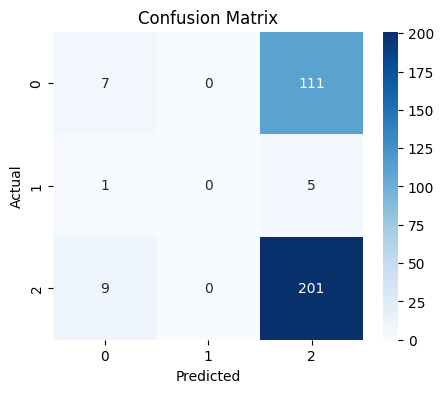

In [76]:
plot_confusion_matrix(y_train, y_train_preds)

Here, the model does not perform well. It correctly predicts around 200 Positive samples but very few Negative samples on the training data. We can also see that the model incorrectly classifies around 110 Negative samples as Positive, which indicates a strong bias toward predicting the Positive class.

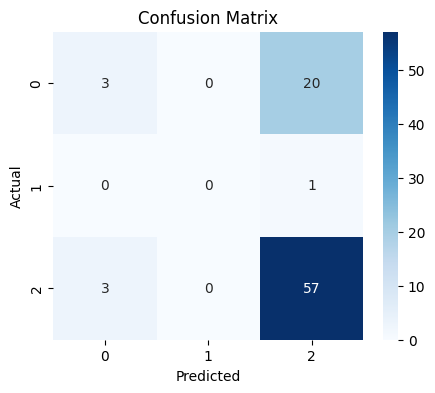

In [77]:
plot_confusion_matrix(y_test, y_test_preds)

Here, we can see that the model predicts most of the news as Positive and produces a very high number of false positives. This clearly confirms that the model is biased toward the Positive class.

In [78]:
train_accuracy_Word2Vec_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the train set is: ",train_accuracy_Word2Vec_NN)
test_accuracy_Word2Vec_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_Word2Vec_NN)
train_f1_score_Word2Vec_NN = f1_score(y_train,y_train_preds,average = 'weighted')
print("The f1 score on the train set is: ",train_f1_score_Word2Vec_NN)
test_f1_score_accuracy_Word2Vec_NN = f1_score(y_test,y_test_preds,average = 'weighted')
print("The f1 score on the test set is: ",test_f1_score_accuracy_Word2Vec_NN)

The accuracy on the train set is:  0.6227544910179641
The accuracy on the test set is:  0.7142857142857143
The f1 score on the train set is:  0.5162478753225154
The f1 score on the test set is:  0.6467123581066611


The model shows relatively low performance on the training data, with an accuracy of around 61% and an F1 score of about 51%. However, the test accuracy and F1 score increase to approximately 71% and 64%. This unusual pattern suggests the model may not be learning meaningful patterns and could be relying heavily on a positive-class bias, rather than genuinely generalizing well.

In [79]:
Word2Vec_NN_train_performance = model_performance_classification_sklearn(y_train,y_train_preds)
Word2Vec_NN_test_performance = model_performance_classification_sklearn(y_test,y_test_preds)
results.loc[4] = ["Word2Vec_NN_M1","-","-", 2, "64-H1, 32-H2","relu",40,64,Word2Vec_NN_train_performance.Accuracy[0],Word2Vec_NN_test_performance.Accuracy[0],Word2Vec_NN_train_performance.F1[0],Word2Vec_NN_test_performance.F1[0],Word2Vec_NN_train_performance.Recall[0],Word2Vec_NN_test_performance.Recall[0],Word2Vec_NN_train_performance.Precision[0],Word2Vec_NN_test_performance.Precision[0]]


**Conclusion**: We observe that the model is underfitting and still shows a strong bias toward predicting the Positive class. To improve this, we increase the number of epochs so the model can learn more from the training data. We also increase the batch size to reduce the frequency of parameter updates and make training more stable.

### Neural Network on **Word2Vec - Model 2 (Word2Vec_NN_M2)**


In [80]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_df_Word2Vec.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))  # 3 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,443 (83.76 KB)

 Trainable params: 21,443 (83.76 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
# Fitting the model
history = model.fit(
    X_train_df_Word2Vec, y_train,
    validation_data=(X_test_df_Word2Vec, y_test),
    epochs=80,
    batch_size=256
)

Epoch 1/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 546ms/step - accuracy: 0.6138 - loss: 0.9687 - val_accuracy: 0.7143 - val_loss: 0.8227
Epoch 2/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6257 - loss: 0.8512 - val_accuracy: 0.7143 - val_loss: 0.7712
Epoch 3/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5689 - loss: 0.8198 - val_accuracy: 0.7143 - val_loss: 0.7316
Epoch 4/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5838 - loss: 0.8052 - val_accuracy: 0.7143 - val_loss: 0.7016
Epoch 5/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5928 - loss: 0.7759 - val_accuracy: 0.7143 - val_loss: 0.6814
Epoch 6/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6138 - loss: 0.7639 - val_accuracy: 0.7143 - val_loss: 0.6693
Epoch 7/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6078 - loss: 0.7547 - val_accuracy: 0.7143 - val_loss: 0.6624
Epoch 8/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6257 - loss: 0.7417 - val_accuracy: 0.7143 - val_loss:

In [82]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train_df_Word2Vec)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [83]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test_df_Word2Vec)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


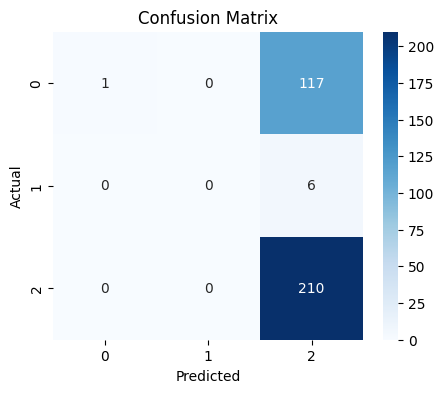

In [84]:
plot_confusion_matrix(y_train, y_train_preds)

Although there is some improvement, the model still tends to predict most news as Positive, indicating a bias toward the Positive class.

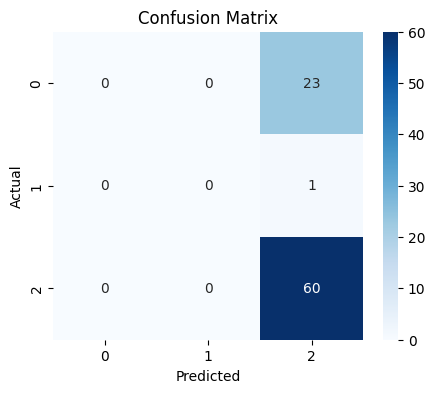

In [85]:
plot_confusion_matrix(y_test, y_test_preds)

On the test data as well, the model shows a strong bias toward predicting the Positive class. This indicates that the model is not generalizing well and is struggling to correctly distinguish between Neutral and Negative samples.

In [86]:
train_accuracy_Word2Vec_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the train set is: ",train_accuracy_Word2Vec_NN)
test_accuracy_Word2Vec_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_Word2Vec_NN)
train_f1_score_Word2Vec_NN = f1_score(y_train,y_train_preds,average = 'weighted')
print("The f1 score on the train set is: ",train_f1_score_Word2Vec_NN)
test_f1_score_accuracy_Word2Vec_NN = f1_score(y_test,y_test_preds,average = 'weighted')
print("The f1 score on the test set is: ",test_f1_score_accuracy_Word2Vec_NN)

The accuracy on the train set is:  0.6317365269461078
The accuracy on the test set is:  0.7142857142857143
The f1 score on the train set is:  0.49225788174799484
The f1 score on the test set is:  0.5952380952380952


In [87]:
Word2Vec_NN_train_performance = model_performance_classification_sklearn(y_train,y_train_preds)
Word2Vec_NN_test_performance = model_performance_classification_sklearn(y_test,y_test_preds)
results.loc[5] = ["Word2Vec_NN_M2","-","-", 2, "64-H1, 32-H2","relu",80,256,Word2Vec_NN_train_performance.Accuracy[0],Word2Vec_NN_test_performance.Accuracy[0],Word2Vec_NN_train_performance.F1[0],Word2Vec_NN_test_performance.F1[0],Word2Vec_NN_train_performance.Recall[0],Word2Vec_NN_test_performance.Recall[0],Word2Vec_NN_train_performance.Precision[0],Word2Vec_NN_test_performance.Precision[0]]


**Conclusion:** The performance has improved compared to the previous model, but the model still appears to be underfitting. To improve it further, we next experiment with a neural network using Sentence Transformer embeddings.

### Neural Network on Sentance transformer Model 1 - (SentenceTransformer_NN_M1)

In [88]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_st_embedding_matrix.shape[1],)))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))  # 3 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,819 (104.76 KB)

 Trainable params: 26,819 (104.76 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
# Fitting the model
history = model.fit(
    X_train_st_embedding_matrix, y_train,
    validation_data=(X_test_st_embedding_matrix, y_test),
    epochs=40,
    batch_size=64
)

Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.4760 - loss: 1.0852 - val_accuracy: 0.7143 - val_loss: 1.0370
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6287 - loss: 1.0268 - val_accuracy: 0.7143 - val_loss: 0.9639
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6287 - loss: 0.9549 - val_accuracy: 0.7143 - val_loss: 0.8724
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6287 - loss: 0.8747 - val_accuracy: 0.7143 - val_loss: 0.7854
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6287 - loss: 0.8159 - val_accuracy: 0.7143 - val_loss: 0.7232
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6287 - loss: 0.7778 - val_accuracy: 0.7143 - val_loss: 0.6870
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6287 - loss: 0.7451 - val_accuracy: 0.7143 - val_loss: 0.6666
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6287 - loss: 0.7226 - val_accuracy: 0.7143 - val_loss: 0.6560


In [90]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train_st_embedding_matrix)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [91]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test_st_embedding_matrix)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


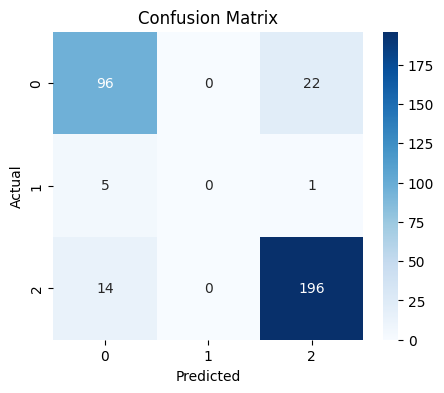

In [92]:
plot_confusion_matrix(y_train, y_train_preds)

On the training data, the model performs well, correctly predicting 195 Positive samples and 99 Negative samples. This indicates strong training performance and a reduced Positive-class bias compared to the other models. However, we will confirm whether this trend holds on the test data as well.

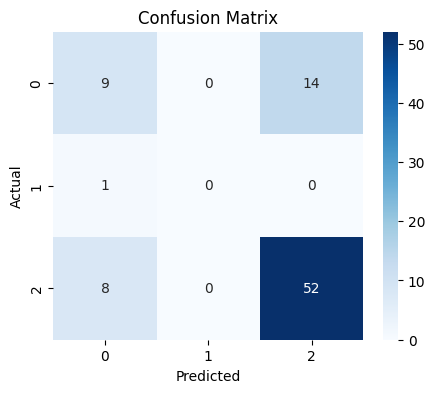

In [93]:
plot_confusion_matrix(y_test, y_test_preds)

We can see that the model correctly predicts around 50 Positive samples and about 10 Negative samples. This indicates that the model is learning both Positive and Negative sentiment better compared to the earlier models. Additionally, we do not observe a strong bias toward predicting only Positive news.


In [94]:
train_accuracy_sentance_embedding_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the train set is: ",train_accuracy_sentance_embedding_NN)
test_accuracy_sentance_embedding_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_sentance_embedding_NN)

print("The F1 score on the train set is: ",f1_score(y_train,y_train_preds,average='weighted'))
print("The F1 score on the test set is: ",f1_score(y_test,y_test_preds,average='weighted'))

The accuracy on the train set is:  0.874251497005988
The accuracy on the test set is:  0.7261904761904762
The F1 score on the train set is:  0.865641207755263
The F1 score on the test set is:  0.7097782202311818


The model achieves strong performance on the training data, with an accuracy of around 88% and an F1 score of approximately 87%. On the test data, the accuracy is about 73% and the F1 score is roughly 71%. This indicates that the model generalizes reasonably well and maintains a good balance between precision and recall.

In [95]:
transformer_NN_train_performance = model_performance_classification_sklearn(y_train,y_train_preds)
transformer_NN_test_performance = model_performance_classification_sklearn(y_test,y_test_preds)
results.loc[6] = ["SentenceTransformer_NN_M1","-","-", 2, "64-H1, 32-H2","relu",40,64,transformer_NN_train_performance.Accuracy[0],transformer_NN_test_performance.Accuracy[0],transformer_NN_train_performance.F1[0],transformer_NN_test_performance.F1[0],transformer_NN_train_performance.Recall[0],transformer_NN_test_performance.Recall[0],transformer_NN_train_performance.Precision[0],transformer_NN_test_performance.Precision[0]]


**Conclusion:** Here the accuracy and F1 score on training data is good ~88% and ~87% and same scores are ~73% and ~71% on test data which shows model is permforming well and has good F1 score. We can try improving this further by tweaking some more parameters in the model.

### Neural Network on Sentance transformer Model 2 - (SentenceTransformer_NN_M2)

In [96]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_st_embedding_matrix.shape[1],)))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))  # 3 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,731 (225.51 KB)

 Trainable params: 57,731 (225.51 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
# Fitting the model
history = model.fit(
    X_train_st_embedding_matrix, y_train,
    validation_data=(X_test_st_embedding_matrix, y_test),
    epochs=20,
    batch_size=36
    )

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5120 - loss: 1.0244 - val_accuracy: 0.7143 - val_loss: 0.9059
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6287 - loss: 0.8486 - val_accuracy: 0.7143 - val_loss: 0.7238
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6287 - loss: 0.7377 - val_accuracy: 0.7143 - val_loss: 0.6604
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6317 - loss: 0.7048 - val_accuracy: 0.7143 - val_loss: 0.6550
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6677 - loss: 0.6873 - val_accuracy: 0.7143 - val_loss: 0.6404
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6647 - loss: 0.6765 - val_accuracy: 0.7143 - val_loss: 0.6168
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6677 - loss: 0.6534 - val_accuracy: 0.7262 - val_loss: 0.6009
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7096 - loss: 0.6272 - val_accuracy: 0.7381 - v

In [98]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train_st_embedding_matrix)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [99]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test_st_embedding_matrix)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


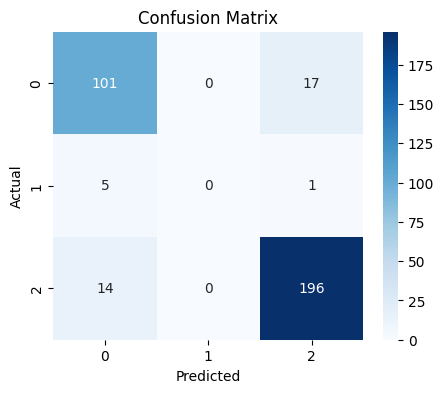

In [100]:
plot_confusion_matrix(y_train, y_train_preds)

On the training data, the model performs well, correctly predicting around 195 Positive samples and about 100 Negative samples. This indicates that the model is learning effectively on the training set and shows less bias toward the Positive class compared to the earlier models. However, we will confirm whether this performance generalizes by evaluating it on the test data.

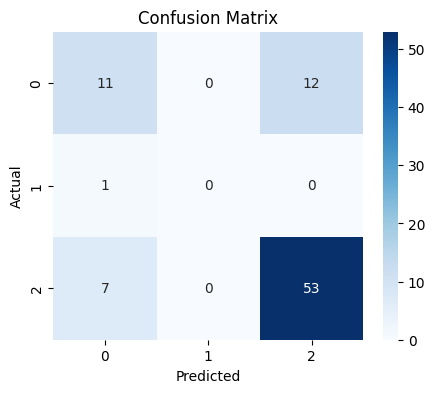

In [101]:
plot_confusion_matrix(y_test, y_test_preds)

The model correctly predicts around 53 Positive samples and about 13 Negative samples, which indicates it is learning both positive and negative sentiment better compared to the other models. Additionally, we do not observe a strong bias toward predicting Positive sentiment.


In [102]:
train_accuracy_sentance_embedding_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the train set is: ",train_accuracy_sentance_embedding_NN)
test_accuracy_sentance_embedding_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_sentance_embedding_NN)

print("The F1 score on the train set is: ",f1_score(y_train,y_train_preds,average='weighted'))
print("The F1 score on the test set is: ",f1_score(y_test,y_test_preds,average='weighted'))

The accuracy on the train set is:  0.8892215568862275
The accuracy on the test set is:  0.7619047619047619
The F1 score on the train set is:  0.8811443230551739
The F1 score on the test set is:  0.7491383219954648


The model achieves strong performance on the training set, with accuracy and F1 score both around 90%. On the test set, the accuracy is approximately 80% and the F1 score is about 78%. This indicates that the model generalizes well to unseen data and maintains a reasonably high F1 score across both training and testing.

In [103]:
transformer_NN_train_performance = model_performance_classification_sklearn(y_train,y_train_preds)
transformer_NN_test_performance = model_performance_classification_sklearn(y_test,y_test_preds)
results.loc[7] = ["SentenceTransformer_NN_M2","-","-", 2, "128-H1, 64-H2","relu",20,36,transformer_NN_train_performance.Accuracy[0],transformer_NN_test_performance.Accuracy[0],transformer_NN_train_performance.F1[0],transformer_NN_test_performance.F1[0],transformer_NN_train_performance.Recall[0],transformer_NN_test_performance.Recall[0],transformer_NN_train_performance.Precision[0],transformer_NN_test_performance.Precision[0]]


**Conlusion** This is the best-performing model so far for sentiment analysis across all classes. It achieves higher recall, precision, and F1 scores, which is especially important given the class imbalance in the dataset. Additionally, the model shows more balanced performance across labels instead of being biased toward a single sentiment category.

Since the dataset contains very few Neutral sentiment samples in the training set, we can experiment with a binary classifier instead of a multi-class classifier. This binary model will predict news as either Positive or Negative.


This leads to an important conclusion: the limited Neutral data may introduce noise during training, which can reduce the model’s ability to correctly distinguish between Positive and Negative sentiments. Additionally, in a stock market context, misclassifying Positive as Negative (or vice versa) has a much greater impact on decision-making than incorrectly classifying Neutral news as Positive or Negative.

###Sentance transformer with neural network for binary sentiment classifier - (SentenceTransformer_NN_BinaryClassifier)

In [104]:
#Create a new copy of stock news
data = stock_news.copy()
#Remove data with label 0
data = data[data['Label'] != 0].reset_index(drop=True)
#Replace -1 with 0, so new labels are 0 -> Negative, 1-> Positive
data['Label'] = data['Label'].replace(-1, 0)

In [105]:
data.shape

(411, 8)

After converting the problem into binary classification, we now have 411 samples with labels 0 and 1. We will next create a train–test split on this dataset to train and evaluate the binary classifier.

In [106]:
#Drop price and volume columns as these do not have impact on label as confirmed in EDA
data = data.drop(['High','Low','Open','Close','Volume'], axis=1)
# Define the target variable (y) and the features (X)
y = data['Label']
X = data.drop('Label', axis=1)

data_2 = data.sort_values("Date")
split = int(len(data_2)*0.8)

X_train = data_2.iloc[:split]
X_test  = data_2.iloc[split:]
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = data_2.iloc[:split]['Label']
y_test = data_2.iloc[split:]['Label']
# Print the shapes of the resulting sets to verify the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (328, 3)
X_test shape: (83, 3)
y_train shape: (328,)
y_test shape: (83,)


Sentence Transformer embeddings are generated for the dataset to convert each news sentence into a numerical vector representation.

In [107]:
#Encoding the news as vectors using sentance transformer. This should help us capture relationship in words by using emcoder.
X_train_st_embedding_matrix = model_st.encode(X_train['News'], show_progress_bar=True)
X_test_st_embedding_matrix = model_st.encode(X_test['News'], show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Next, we train a neural network model on the same dataset to compare its performance with the existing three-class sentiment classifier.

In [108]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(128, activation='gelu', input_shape=(X_train_st_embedding_matrix.shape[1],)))
model.add(Dropout(0.5))
model.add(Dense(32, activation='gelu'))
model.add(Dense(2, activation='softmax'))  # 2 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,474 (208.88 KB)

 Trainable params: 53,474 (208.88 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
# Fitting the model
history = model.fit(
    X_train_st_embedding_matrix, y_train,
    validation_data=(X_test_st_embedding_matrix, y_test),
    epochs=26,
    batch_size=64
  )

Epoch 1/26
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6067 - loss: 0.6801 - val_accuracy: 0.7229 - val_loss: 0.6376
Epoch 2/26
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6433 - loss: 0.6539 - val_accuracy: 0.7229 - val_loss: 0.6167
Epoch 3/26
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6433 - loss: 0.6386 - val_accuracy: 0.7229 - val_loss: 0.6035
Epoch 4/26
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6402 - loss: 0.6292 - val_accuracy: 0.7229 - val_loss: 0.5931
Epoch 5/26
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6402 - loss: 0.6169 - val_accuracy: 0.7229 - val_loss: 0.5838
Epoch 6/26
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6677 - loss: 0.6001 - val_accuracy: 0.7229 - val_loss: 0.5720
Epoch 7/26
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6890 - loss: 0.5840 - val_accuracy: 0.7349 - val_loss: 0.5577
Epoch 8/26
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7287 - loss: 0.5652 - val_accuracy: 0.7590 - val_loss: 0.5429


In [110]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train_st_embedding_matrix)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [111]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test_st_embedding_matrix)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


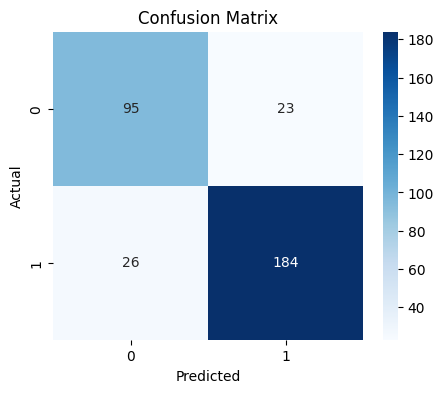

In [112]:
plot_confusion_matrix(y_train, y_train_preds)

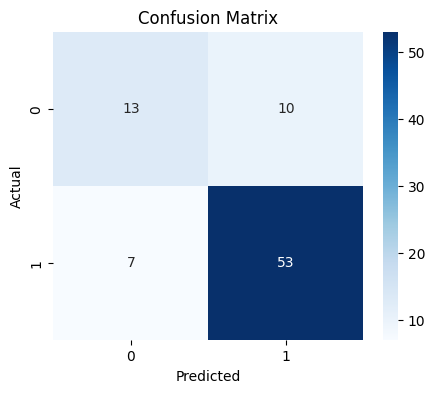

In [113]:
plot_confusion_matrix(y_test, y_test_preds)

In [114]:
train_accuracy_sentance_embedding_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the train set is: ",train_accuracy_sentance_embedding_NN)
test_accuracy_sentance_embedding_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_sentance_embedding_NN)

print("The F1 score on the train set is: ",f1_score(y_train,y_train_preds,average='weighted'))
print("The F1 score on the test set is: ",f1_score(y_test,y_test_preds,average='weighted'))
print("The recall score on the train set is: ",recall_score(y_train,y_train_preds,average='weighted'))
print("The recall score on the test set is: ",recall_score(y_test,y_test_preds,average='weighted'))

The accuracy on the train set is:  0.850609756097561
The accuracy on the test set is:  0.7951807228915663
The F1 score on the train set is:  0.8510099767925224
The F1 score on the test set is:  0.7905336604500817
The recall score on the train set is:  0.850609756097561
The recall score on the test set is:  0.7951807228915663


Model achieves better recall, precision, F1 score, and accuracy compared to previous approaches. Therefore, it is a strong choice if we want to perform binary sentiment classification instead of a three-class classification.

In [115]:
transformer_NN_train_performance = model_performance_classification_sklearn(y_train,y_train_preds)
transformer_NN_test_performance = model_performance_classification_sklearn(y_test,y_test_preds)
results.loc[8] = ["SentenceTransformer_NN_BinaryClassifier","-","-", 2, "128-H1, 32-H2","gelu",26,64,transformer_NN_train_performance.Accuracy[0],transformer_NN_test_performance.Accuracy[0],transformer_NN_train_performance.F1[0],transformer_NN_test_performance.F1[0],transformer_NN_train_performance.Recall[0],transformer_NN_test_performance.Recall[0],transformer_NN_train_performance.Precision[0],transformer_NN_test_performance.Precision[0]]

### **Model Performance Summary and Final Model Selection**

In [116]:
#Output performance for all models
results

,Model Name,Estimators,Max depth,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,Train Accuracy,Test Accuracy,Train F1,Test F1,Train Recall,Test Recall,Train Precision,Test Precision
0,Word2Vec_RF_M1,100,3,-,-,-,-,-,0.754491,0.726190,0.719303,0.654768,0.754491,0.726190,0.776387,0.688698
1,Word2Vec_RF_M2,100,4,-,-,-,-,-,0.805389,0.738095,0.780974,0.687065,0.805389,0.738095,0.828847,0.706845
2,SentanceTransformer_RF_M1,100,4,-,-,-,-,-,0.790419,0.714286,0.760758,0.595238,0.790419,0.714286,0.824850,0.510204
3,SentanceTransformer_RF_M2,200,4,-,-,-,-,-,0.904192,0.702381,0.893782,0.624933,0.904192,0.702381,0.898896,0.624895
4,Word2Vec_NN_M1,-,-,2,"64-H1, 32-H2",relu,40,64,0.622754,0.714286,0.516248,0.646712,0.622754,0.714286,0.544140,0.658883
5,Word2Vec_NN_M2,-,-,2,"64-H1, 32-H2",relu,80,256,0.631737,0.714286,0.492258,0.595238,0.631737,0.714286,0.749798,0.510204
6,SentenceTransformer_NN_M1,-,-,2,"64-H1, 32-H2",relu,40,64,0.874251,0.726190,0.865641,0.709778,0.874251,0.726190,0.857633,0.699675
7,SentenceTransformer_NN_M2,-,-,2,"128-H1, 64-H2",relu,20,36,0.889222,0.761905,0.881144,0.749138,0.889222,0.761905,0.873213,0.740939
8,SentenceTransformer_NN_BinaryClassifier,-,-,2,"128-H1, 32-H2",gelu,26,64,0.850610,0.795181,0.851010,0.790534,0.850610,0.795181,0.851559,0.788267


**Observations:**

1. Model #8 (SentenceTransformer_NN_M2) shows the best overall performance among all models for the three-class sentiment classification task. Therefore, it can be used to classify stock news into Negative, Neutral, and Positive labels.

2. Since the dataset contains very few Neutral samples, removing the Neutral class results in a slight improvement in performance. This binary model can be used when the news has already been identified as stock-impacting and the goal is to determine only the final Positive vs Negative sentiment.

3. Overall, the combination of a Neural Network with Sentence Transformer embeddings performs best for stock news sentiment analysis. This highlights that context-aware transformer embeddings capture richer semantic meaning, leading to more accurate and reliable sentiment predictions.



## **Conclusions and Recommendations**

* A news sentiment analysis system was successfully developed using two embedding approaches: Word2Vec and Sentence Transformer models. This system enables classification of news into Positive, Negative, and Neutral sentiment categories.

* The Sentence Transformer–based models consistently outperformed Word2Vec by capturing richer contextual semantics, resulting in more accurate and reliable sentiment predictions.

* Since the dataset contains very limited Neutral samples, future improvements should focus on collecting more Neutral-labelled news to strengthen the model’s ability to learn Neutral sentiment patterns.

* The SentenceTransformer_NN_BinaryClassifier is a strong option when we are confident that the news is stock-related and expresses either Positive or Negative sentiment. This model can also be integrated into a two-stage pipeline where a separate classifier first filters out Neutral or non-impactful news, and the remaining impactful news is then passed to the binary classifier for final sentiment prediction.

* The results also show that context-aware embeddings are more effective for financial news sentiment analysis compared to traditional word-level embeddings, especially when the news contains complex phrasing or indirect sentiment.

* Finally, a structured evaluation approach using train/test metrics and confusion matrices helped identify model bias and ensured the selected model performs well across all sentiment classes, not just the majority class.

<font size=6 color='blue'>Power Ahead</font>
___